> **Paper work:** prefer [`march18_paper_candidates.ipynb`](march18_paper_candidates.ipynb) and `malca.review.paper_candidates` for canonical migrated paths and full feature coverage.

# LTV Candidate Review Separability

This notebook inspects the reviewed LTV-candidate queue in `output/ltv/ltv/ltv_candidates.db`.
It is meant to answer four practical questions:

- What was actually reviewed, and which candidates are in each human label bucket?
- Which measured features differ between `event_class='ltv'` and `event_class='instrumental'`?
- Do simple statistical tests or baseline classifiers suggest separability?
- What do the `other`, `unknown_interesting`, and `dipper` reviewed subsets look like?

The notebook is read-only with respect to the review DB.


## Setup

The path resolution below works whether the notebook is opened from the repo root or from notebook subfolders.


In [1]:
from __future__ import annotations

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import json
import math
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

from malca.notebook_paths import find_repo_root
from malca.lightcurve_publication import (
    FIG_LC_SINGLE_COL,
    FIG_ROC_PR_TWO_COL,
    FIG_TWO_COL_WIDTH,
    figsize_feature_grid,
    figsize_heatmap_two_col,
)
from malca.review.paper_candidates import paper_feature_columns, resolve_paper_paths

REPO_ROOT = find_repo_root()
PATHS = resolve_paper_paths(REPO_ROOT)
RUN_DIR = PATHS["march18_run"]
DB_PATH = PATHS["review_db"]
LIGHTCURVE_DIRS = [PATHS["lightcurve_dir"]]

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DB_PATH   = {DB_PATH}")
print(f"exists    = {DB_PATH.exists()}")


REPO_ROOT = /Users/calder/code/malca
DB_PATH   = /Users/calder/code/malca/output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/review/review.taxonomy_filled.db
exists    = True


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Reviewed Candidates

This joins `candidates` to `reviews` and keeps both reviewed rows and the full imported queue for completion checks.


In [2]:
if not DB_PATH.exists():
    raise FileNotFoundError(DB_PATH)

with sqlite3.connect(DB_PATH) as conn:
    reviewed = pd.read_sql_query(
        """
        SELECT
            c.*,
            r.status AS review_status,
            r.interest_score,
            r.event_class,
            r.review_pass,
            r.notes,
            r.reviewer,
            r.updated_at
        FROM candidates c
        JOIN reviews r USING(candidate_id)
        WHERE COALESCE(r.status, '') NOT IN ('', 'unreviewed')
        """,
        conn,
    )
    all_candidates = pd.read_sql_query("SELECT * FROM candidates", conn)
    reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
    app_state = pd.read_sql_query("SELECT * FROM app_state", conn)

reviewed["updated_at"] = pd.to_datetime(reviewed["updated_at"], errors="coerce", utc=True)
for col in ["interest_score", "review_pass"]:
    reviewed[col] = pd.to_numeric(reviewed[col], errors="coerce")

print(f"All candidates in DB: {len(all_candidates):,}")
print(f"Reviewed rows:        {len(reviewed):,}")
print(f"Review rows:          {len(reviews):,}")
print(f"Unreviewed/missing:   {len(all_candidates) - len(reviews):,}")
display(reviewed["event_class"].value_counts(dropna=False).rename_axis("event_class").reset_index(name="n"))
display(app_state.loc[app_state["key"].isin(["review_last_candidate", "last_input_file"])])


All candidates in DB: 9,569
Reviewed rows:        1,370
Review rows:          1,370
Unreviewed/missing:   8,199


,event_class,n
0,unknown_interesting,708
1,instrumental,418
2,other,89
3,brightening_event,41
4,ltv,36
5,microlensing,34
6,dipper,20
7,unclear,8
8,quasi_periodic,6
9,periodic,5


,key,value,updated_at
0,last_input_file,/Users/calder/code/malca/output_migrated_camer...,2026-06-17T16:16:18.196359+00:00
1,review_last_candidate,223338997633,2026-06-17T19:33:35.280536+00:00


## Candidate Tables

These are compact review tables for each label. The variables stay in memory, so change `max_rows` or `sort_by` to inspect more rows.


In [3]:
KEY_DISPLAY_COLS = [
    "candidate_id", "asas_sn_id", "event_class", "review_status", "interest_score", "review_pass",
    "updated_at", "notes", "lc_path",
    "ltv_slope", "ltv_dispersion", "ltv_max_diff", "ltv_median", "ltv_ls_power", "ltv_ls_fap",
    "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "ltv_passed_filters", "ltv_dust_candidate",
    "ltv_vsx_match", "ltv_milliquas_match", "ltv_gaia_alert_match",
    "baseline_mag", "n_points", "n_cameras", "pm_total", "ruwe",
    "periodicity_score", "dipper_score", "jumper_score", "catalog_match", "catalog_source",
    "asassn_var_type", "gaia_var_class", "simbad_otype", "ztf_var_type", "microlens_match",
]
KEY_DISPLAY_COLS = [c for c in KEY_DISPLAY_COLS if c in reviewed.columns]

CLASS_ORDER = ["ltv", "instrumental", "other", "unknown_interesting", "dipper"]

def candidate_table(label: str | None = None, max_rows: int = 80, sort_by: str = "interest_score") -> pd.DataFrame:
    data = reviewed.copy()
    if label is not None:
        data = data.loc[data["event_class"].eq(label)].copy()
    sort_cols = [c for c in [sort_by, "updated_at", "candidate_id"] if c in data.columns]
    ascending = [False if c in {"interest_score", "updated_at"} else True for c in sort_cols]
    if sort_cols:
        data = data.sort_values(sort_cols, ascending=ascending)
    return data[KEY_DISPLAY_COLS].head(max_rows)

for label in CLASS_ORDER:
    display(Markdown(f"### {label}: {int((reviewed['event_class'] == label).sum())} reviewed"))
    display(candidate_table(label, max_rows=80))


### ltv: 36 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
1249,532576812012,532576812012,ltv,reviewed,4,4,2026-06-10 19:02:53.330015+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.101138,1561.0,3.0,None,NaN,NaN,0.000000,0.424206,0,,,,,,None
412,352188082317,352188082317,ltv,reviewed,4,2,2026-03-20 02:01:39.585016+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.622000,1015.0,6.0,None,2.994734,NaN,20.362103,0.000000,0,,,,,,None
1130,326418682923,326418682923,ltv,reviewed,4,2,2026-03-19 08:51:35.261872+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.139028,1025.0,5.0,None,NaN,NaN,0.000000,-1.364057,0,,,,,,None
1037,163209477162,163209477162,ltv,reviewed,4,2,2026-03-19 04:57:01.548433+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,14.298272,1409.0,8.0,None,NaN,NaN,0.000000,2.217345,0,,ROT:,,*,,None
859,523986746107,523986746107,ltv,reviewed,4,2,2026-03-19 04:46:30.330089+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.685268,2352.0,5.0,None,NaN,NaN,-0.104598,0.000000,0,,,,SB*,,None
491,584116537767,584116537767,ltv,reviewed,4,2,2026-03-19 04:35:17.432328+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.036444,1213.0,3.0,None,1.087681,NaN,-inf,1.833019,0,,,,Em*,,None
1070,214749434145,214749434145,ltv,reviewed,3,3,2026-06-02 04:35:07.363154+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.935372,1092.0,5.0,None,NaN,NaN,0.000000,15.983831,0,,,,,,None
1113,300648281213,300648281213,ltv,reviewed,3,2,2026-03-20 02:00:42.555151+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.151742,1246.0,5.0,None,NaN,NaN,20.389173,0.000000,0,,,,*,,None
94,34360526644,34360526644,ltv,reviewed,3,2,2026-03-19 11:50:38.301606+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.841955,412.0,3.0,None,NaN,NaN,22.962997,20.891478,0,,,,,,None
342,163209716952,163209716952,ltv,reviewed,2,3,2026-06-10 18:40:03.447660+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.486516,2307.0,6.0,None,1.176501,NaN,0.783384,0.000000,0,,,,*,,None


### instrumental: 418 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
210,549756666330,549756666330,instrumental,reviewed,4,3,2026-06-10 19:32:40.436645+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.114569,785.0,3.0,None,NaN,NaN,0.000000,19.649333,0,,,,,,None
469,541166692834,541166692834,instrumental,reviewed,4,3,2026-06-10 19:32:27.155018+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,11.622098,1104.0,3.0,None,0.841044,NaN,0.000000,20.857701,0,,,,,,None
202,541165961203,541165961203,instrumental,reviewed,4,3,2026-06-10 19:03:03.322727+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.575585,1449.0,4.0,None,NaN,NaN,0.000000,19.689612,0,,,,,,None
866,532576259560,532576259560,instrumental,reviewed,4,3,2026-06-10 19:00:58.407842+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.498627,1622.0,3.0,None,NaN,NaN,0.000000,21.937990,0,,,,,,None
1246,523987031703,523987031703,instrumental,reviewed,4,3,2026-06-10 18:59:31.679791+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.908394,1586.0,3.0,None,NaN,NaN,0.000000,20.096138,0,,,,,,None
848,515397129243,515397129243,instrumental,reviewed,4,3,2026-06-10 18:55:39.507354+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.888867,915.0,3.0,None,NaN,NaN,0.000000,19.553213,0,,,,*,,None
1234,515396228823,515396228823,instrumental,reviewed,4,3,2026-06-10 18:55:29.395410+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.435908,1255.0,4.0,None,NaN,NaN,0.000000,21.480281,0,,,,,,None
179,506807056724,506807056724,instrumental,reviewed,4,3,2026-06-10 18:54:02.586673+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,11.988491,1110.0,5.0,None,NaN,NaN,0.000000,18.683570,0,,,,*,,None
841,506806640360,506806640360,instrumental,reviewed,4,3,2026-06-10 18:53:55.438065+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.085000,859.0,3.0,None,NaN,NaN,0.000000,20.729144,0,,,,,,None
1118,309238849400,309238849400,instrumental,reviewed,4,3,2026-06-02 22:10:05.627760+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.148277,935.0,5.0,None,NaN,NaN,0.000000,19.388660,0,,,,,,None


### other: 89 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
290,652835815168,652835815168,other,reviewed,4,2,2026-03-20 21:09:36.701018+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.968122,1204.0,3.0,None,NaN,NaN,0.000000,22.778900,0,,,,,,None
419,386547289419,386547289419,other,reviewed,4,3,2026-03-20 20:48:12.024244+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.371770,1201.0,6.0,None,1.018635,NaN,19.867276,0.000000,0,,ROT:,YSO,SB*,,None
456,515396207917,515396207917,other,reviewed,4,2,2026-03-20 20:18:11.810720+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,11.994506,1499.0,4.0,None,1.204014,NaN,0.000000,20.035418,0,,,,RR*,,None
437,472446626839,472446626839,other,reviewed,4,2,2026-03-20 19:51:10.047589+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.237051,1008.0,4.0,None,0.834857,NaN,12.493998,0.000000,0,,,,EB*,,None
907,584115779011,584115779011,other,reviewed,4,2,2026-03-20 06:39:57.740125+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.485041,2093.0,6.0,None,NaN,NaN,18.042140,0.000000,0,,,,EB*,,None
526,652835797559,652835797559,other,reviewed,4,2,2026-03-20 06:38:22.372817+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.273613,1138.0,3.0,None,0.985791,NaN,18.205948,0.000000,0,,,,,,None
535,68720667043,68720667043,other,reviewed,4,2,2026-03-20 05:46:32.353666+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.294000,669.0,2.0,None,0.821292,NaN,19.556165,0.000000,0,,,,EB*,,None
93,343598268424,343598268424,other,reviewed,4,2,2026-03-20 05:26:29.430884+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.989107,2350.0,6.0,None,NaN,NaN,20.705012,-0.441348,0,,YSO,,,,None
1081,240519014553,240519014553,other,reviewed,4,2,2026-03-20 05:26:12.668185+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.492181,926.0,6.0,None,NaN,NaN,20.723628,-0.218134,0,,YSO,,LP*,,None
676,274878275229,274878275229,other,reviewed,4,2,2026-03-20 02:20:27.828023+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.679791,991.0,4.0,None,NaN,NaN,20.105618,0.000000,0,,,,EB*,,None


### unknown_interesting: 708 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
229,584115757436,584115757436,unknown_interesting,needs_followup,4,1,2026-03-22 17:14:31.648862+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.669065,1108.0,3.0,None,NaN,NaN,0.000000,16.382227,0,,,DSCT|GDOR|SXPHE,Pu*,,None
244,601295591834,601295591834,unknown_interesting,needs_followup,4,1,2026-03-22 17:14:13.951231+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.747103,1251.0,4.0,None,NaN,3.0,0.000000,-0.467168,1,asassn_var,ROT:,,*,,None
724,343597961057,343597961057,unknown_interesting,reviewed,4,1,2026-03-22 16:27:03.037328+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.571922,1015.0,5.0,None,NaN,3.0,22.950320,0.000000,1,ztf_periodic,,,EB*,EA,None
1368,94490667944,94490667944,unknown_interesting,reviewed,4,3,2026-03-20 21:25:39.987860+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.190754,663.0,4.0,None,NaN,NaN,0.000000,21.368117,0,,,,,,None
320,94490663224,94490663224,unknown_interesting,reviewed,4,2,2026-03-20 21:25:14.987547+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.614831,696.0,4.0,None,NaN,NaN,0.000000,-1.801169,0,,,,Em*,,None
1366,94490543907,94490543907,unknown_interesting,reviewed,4,2,2026-03-20 21:24:59.908670+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.403983,824.0,2.0,None,NaN,NaN,0.000000,-0.766676,0,,,,,,None
1350,85899736527,85899736527,unknown_interesting,reviewed,4,2,2026-03-20 21:22:04.737861+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.144975,572.0,3.0,None,NaN,NaN,0.000000,21.682697,0,,,,,,None
310,77310113008,77310113008,unknown_interesting,reviewed,4,2,2026-03-20 21:21:35.172636+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.708599,364.0,2.0,None,NaN,NaN,0.000000,15.677000,0,,,,Em*,,None
1344,68720339248,68720339248,unknown_interesting,reviewed,4,2,2026-03-20 21:13:18.921978+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.505707,1104.0,3.0,None,NaN,NaN,0.000000,0.578188,0,,,,,,None
979,661425400860,661425400860,unknown_interesting,reviewed,4,2,2026-03-20 21:11:19.165443+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.665000,1129.0,3.0,None,NaN,NaN,0.000000,-1.763190,0,,,,,,None


### dipper: 20 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
657,249109084130,249109084130,dipper,reviewed,4,2,2026-03-19 05:19:56.656011+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.954414,2644.0,9.0,None,NaN,NaN,0.000000,-0.404836,0,,,,Y*O,,None
33,180388903123,180388903123,dipper,reviewed,4,2,2026-03-19 04:41:57.365051+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.572548,1104.0,5.0,None,NaN,NaN,-1.040463,0.000000,0,,,,*,,None
1224,498216222923,498216222923,dipper,reviewed,3,3,2026-03-20 20:06:46.892226+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.097669,1115.0,3.0,None,NaN,NaN,0.332474,0.000000,0,,,,,,None
360,240518636016,240518636016,dipper,reviewed,2,2,2026-06-10 18:48:29.416974+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.345930,1007.0,5.0,None,1.566879,NaN,19.800610,18.639169,0,,,,*,,None
794,446676921101,446676921101,dipper,reviewed,2,3,2026-06-01 18:10:39.761894+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.949305,1729.0,5.0,None,NaN,NaN,-0.560155,0.000000,0,,,,,,None
206,549755992463,549755992463,dipper,reviewed,2,5,2026-06-01 18:05:18.438723+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.928863,1109.0,3.0,None,NaN,NaN,-1.425498,0.000000,0,,,,,,None
864,532576054353,532576054353,dipper,reviewed,2,2,2026-03-20 06:43:15.433996+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.630545,2380.0,6.0,None,NaN,NaN,17.788846,0.000000,0,,,,,,None
636,223338997633,223338997633,dipper,reviewed,1,2,2026-03-20 20:49:57.550421+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.594424,1097.0,6.0,None,NaN,NaN,19.852360,0.000000,0,,,,,,None
545,8591303502,8591303502,dipper,reviewed,1,2,2026-03-20 20:07:24.393034+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.191586,1329.0,5.0,None,0.891140,NaN,0.102236,0.000000,0,,,,Em*,,None
194,523986354332,523986354332,dipper,reviewed,1,2,2026-03-20 19:59:19.205763+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.289000,1031.0,4.0,None,NaN,NaN,1.291065,0.000000,0,,,,*,,None


## Group-Level Review Summary

Use this to catch review-label distribution issues before interpreting statistical differences. In this set, note that `interest_score` is a human-review field, so it is not used as a predictive feature later.


In [4]:
review_summary = (
    reviewed.groupby("event_class", dropna=False)
    .agg(
        n=("candidate_id", "size"),
        mean_interest=("interest_score", "mean"),
        median_interest=("interest_score", "median"),
        high_interest=("interest_score", lambda s: int((s >= 3).sum())),
        min_updated=("updated_at", "min"),
        max_updated=("updated_at", "max"),
    )
    .sort_values("n", ascending=False)
)
review_summary["high_interest_frac"] = review_summary["high_interest"] / review_summary["n"]
display(review_summary)

reviewed_by_pass = pd.crosstab(reviewed["event_class"], reviewed["review_pass"], margins=True)
display(reviewed_by_pass)


,n,mean_interest,median_interest,high_interest,min_updated,max_updated,high_interest_frac
event_class,,,,,,,
unknown_interesting,708,3.834746,4.0,668,2026-03-19 04:41:26.774974+00:00,2026-03-22 17:15:30.027911+00:00,0.943503
instrumental,418,3.157895,4.0,298,2026-03-19 04:51:22.309975+00:00,2026-06-10 19:32:40.436645+00:00,0.712919
other,89,3.258427,4.0,68,2026-03-19 04:40:57.793889+00:00,2026-03-20 21:10:10.902643+00:00,0.764045
brightening_event,41,3.560976,4.0,34,2026-06-02 02:33:30.770387+00:00,2026-06-10 19:32:20.761423+00:00,0.829268
ltv,36,1.833333,1.0,9,2026-03-19 04:35:17.432328+00:00,2026-06-10 19:02:53.330015+00:00,0.250000
microlensing,34,1.911765,1.0,11,2026-03-19 05:06:26.081986+00:00,2026-06-10 19:06:10.044284+00:00,0.323529
dipper,20,1.600000,1.0,3,2026-03-19 04:41:57.365051+00:00,2026-06-10 18:48:29.416974+00:00,0.150000
unclear,8,4.000000,4.0,8,2026-06-01 20:05:46.633440+00:00,2026-06-02 23:42:19.922540+00:00,1.000000
quasi_periodic,6,3.833333,4.0,6,2026-06-02 22:02:47.094494+00:00,2026-06-02 23:42:10.188634+00:00,1.000000


review_pass,1,2,3,4,5,All
event_class,,,,,,
brightening_event,0,1,35,4,1,41
dipper,0,17,2,0,1,20
flare,0,1,1,0,1,3
instrumental,5,310,94,7,2,418
ltv,0,28,7,1,0,36
microlensing,4,21,6,3,0,34
mixed_dip_and_burst,0,0,1,0,1,2
other,0,87,2,0,0,89
periodic,0,0,3,2,0,5


## Feature Preparation

This cell builds analysis feature sets from numeric columns and low-cardinality categorical/flag columns. It excludes human-review fields and IDs.


In [5]:
# A few useful derived columns.
analysis = reviewed.copy()
for col in ["ltv_slope", "ltv_slope_quad", "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "pmra", "pmdec"]:
    if col in analysis.columns:
        analysis[f"abs_{col}"] = pd.to_numeric(analysis[col], errors="coerce").abs()

if {"pmra", "pmdec"}.issubset(analysis.columns) and "pm_total" not in analysis.columns:
    analysis["pm_total"] = np.sqrt(pd.to_numeric(analysis["pmra"], errors="coerce") ** 2 + pd.to_numeric(analysis["pmdec"], errors="coerce") ** 2)

EXCLUDE_FEATURES = {
    "interest_score", "review_pass", "updated_at", "candidate_id", "asas_sn_id", "source_path",
    "lc_path", "payload_json", "imported_at", "review_status", "event_class", "notes", "reviewer",
}

numeric_cols = []
for col in analysis.columns:
    if col in EXCLUDE_FEATURES:
        continue
    s = pd.to_numeric(analysis[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() >= 25 and s.nunique(dropna=True) > 1:
        numeric_cols.append(col)
        analysis[col] = s

# Keep all model/test inputs finite. Some ratio and score fields use inf sentinels.
for col in numeric_cols:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

low_card_cols = []
for col in analysis.columns:
    if col in EXCLUDE_FEATURES or col in numeric_cols:
        continue
    nunique = analysis[col].nunique(dropna=True)
    nonmissing = analysis[col].notna().sum()
    if 2 <= nunique <= 20 and nonmissing >= 25:
        low_card_cols.append(col)

print(f"Numeric analysis columns: {len(numeric_cols)}")
print(f"Low-cardinality categorical columns: {len(low_card_cols)}")
print("Numeric examples:", numeric_cols[:30])
print("Categorical examples:", low_card_cols[:30])


Numeric analysis columns: 227
Low-cardinality categorical columns: 15
Numeric examples: ['catalog_match', 'period_n_sources', 'period_consensus_days', 'period_consensus_agree', 'period_conflict_flag', 'period_consensus_support', 'high_ruwe_flag', 'lsp_period', 'lsp_is_significant', 'dip_significant', 'dip_best_delta_bic', 'dip_best_width_param', 'dip_symmetry_score', 'dip_best_amp', 'dip_best_t0', 'dip_best_alpha', 'dip_bayes_factor', 'dip_best_p', 'dip_best_mag_event', 'dip_trigger_max', 'dip_max_event_prob', 'dip_count', 'dip_run_count', 'dip_max_run_points', 'dip_max_run_duration', 'dip_max_run_sum', 'dip_max_run_max', 'dip_max_run_cameras', 'dip_max_log_bf_local', 'jump_significant']
Categorical examples: ['catalog_source', 'period_sources', 'period_primary_source', 'dip_best_morph', 'jump_best_morph', 'population', 'sfr_name', 'cluster_name', 'asassn_var_type', 'gaia_var_class', 'ztf_var_type', 'gaia_eb_morph', 'alerce_lc_class', 'alerce_stamp_class', 'baseline_source']


## Hand-Picked LTV Metrics By Class

These are the most interpretable LTV and quality-control fields. The broader statistical scan follows in the next section.


In [6]:
INTERPRETABLE_FEATURES = [
    "ltv_slope", "abs_ltv_slope", "ltv_slope_quad", "abs_ltv_slope_quad", "ltv_dispersion", "ltv_max_diff",
    "ltv_median", "ltv_median_err", "ltv_ls_power", "ltv_ls_fap", "ltv_coeff1", "ltv_coeff2",
    "ltv_vg_overlap_days", "ltv_vg_overlap_fraction", "ltv_neowise_w1_slope", "abs_ltv_neowise_w1_slope",
    "ltv_neowise_w1_w2_slope", "abs_ltv_neowise_w1_w2_slope", "ltv_neowise_n_epochs",
    "baseline_mag", "n_points", "n_cameras", "pm_total", "ruwe", "A_v_3d", "ebv_3d",
    "periodicity_score", "periodicity_bootstrap_sig", "lsp_power", "lsp_period", "pdm_snr", "ce_snr",
    "stats_photometry_std_mag", "stats_photometry_robust_sigma_mag", "stats_amplitude", "stats_percent_amplitude",
    "stats_variability_reduced_chi2_vs_constant", "stats_variability_stetson_J", "stats_variability_stetson_L",
    "dipper_score", "jumper_score",
]
INTERPRETABLE_FEATURES = [c for c in INTERPRETABLE_FEATURES if c in analysis.columns and c in numeric_cols]

def grouped_numeric_summary(features: list[str]) -> pd.DataFrame:
    rows = []
    for feature in features:
        for label, group in analysis.groupby("event_class", dropna=False):
            x = pd.to_numeric(group[feature], errors="coerce").dropna()
            rows.append({
                "feature": feature,
                "event_class": label,
                "n": len(x),
                "missing_frac": 1 - len(x) / max(len(group), 1),
                "mean": x.mean() if len(x) else np.nan,
                "std": x.std(ddof=1) if len(x) > 1 else np.nan,
                "median": x.median() if len(x) else np.nan,
                "q25": x.quantile(0.25) if len(x) else np.nan,
                "q75": x.quantile(0.75) if len(x) else np.nan,
            })
    return pd.DataFrame(rows)

summary_long = grouped_numeric_summary(INTERPRETABLE_FEATURES)
display(summary_long.pivot_table(index="feature", columns="event_class", values="median", aggfunc="first"))
display(summary_long.head(40))

PAPER_STATS_FEATURES = paper_feature_columns("LC Variability") + paper_feature_columns("LC Photometric Scatter")
PAPER_LTV_MS_FEATURES = paper_feature_columns("LTV Multi-Survey")
INTERPRETABLE_FEATURES = list(dict.fromkeys(list(INTERPRETABLE_FEATURES) + PAPER_STATS_FEATURES + PAPER_LTV_MS_FEATURES))


event_class,brightening_event,dipper,flare,instrumental,ltv,microlensing,mixed_dip_and_burst,other,periodic,quasi_periodic,unclear,unknown_interesting
feature,,,,,,,,,,,,
A_v_3d,0.095587,0.087820,0.493247,0.092002,0.112000,0.687735,1.641928,0.128568,0.000000,0.154779,0.216436,0.000000
baseline_mag,13.312720,12.840628,13.557998,12.778109,12.962689,13.114263,12.800939,13.138825,13.483285,12.979501,13.585885,13.148639
dipper_score,0.000000,17.141678,0.000000,0.000000,19.534391,0.000000,-2.232892,18.205948,-0.683881,0.000000,0.000000,19.666351
ebv_3d,0.237132,0.175835,0.381252,0.075695,0.056742,0.544329,0.529654,0.170361,0.093531,0.165016,0.201445,0.146041
jumper_score,0.514576,0.000000,21.037343,19.827363,0.000000,0.286013,6.970865,0.000000,0.000000,0.639718,0.174829,0.000000
lsp_period,467.829987,281.244995,NaN,3.447600,392.896004,182.013384,591.900024,37.718999,5.300650,NaN,466.690002,2.186000
n_cameras,5.000000,5.000000,5.000000,4.000000,5.000000,3.000000,6.000000,4.000000,6.000000,4.500000,3.500000,4.000000
n_points,1134.000000,1101.500000,894.000000,1114.000000,1256.500000,1084.500000,1606.500000,1115.000000,2124.000000,1026.500000,860.500000,1088.500000
ruwe,1.104099,1.017348,NaN,1.028652,1.176501,1.275005,NaN,0.918093,NaN,0.926175,NaN,1.026257


,feature,event_class,n,missing_frac,mean,std,median,q25,q75
0,baseline_mag,brightening_event,41,0.000000,13.259815,0.525902,13.312720,12.903631,13.743703
1,baseline_mag,dipper,20,0.000000,12.884052,0.809935,12.840628,12.455483,13.584388
2,baseline_mag,flare,3,0.000000,13.469689,0.155702,13.557998,13.423953,13.559579
3,baseline_mag,instrumental,418,0.000000,12.706922,0.729513,12.778109,12.123805,13.317926
4,baseline_mag,ltv,36,0.000000,12.950505,0.776340,12.962689,12.547549,13.494387
5,baseline_mag,microlensing,34,0.000000,13.123231,0.547511,13.114263,12.597933,13.573007
6,baseline_mag,mixed_dip_and_burst,2,0.000000,12.800939,0.196547,12.800939,12.731449,12.870429
7,baseline_mag,other,89,0.000000,13.204420,0.826571,13.138825,12.597315,13.539871
8,baseline_mag,periodic,5,0.000000,13.246043,0.461673,13.483285,12.899539,13.565159
9,baseline_mag,quasi_periodic,6,0.000000,13.031617,0.637902,12.979501,12.728783,13.316413


## LTV vs Instrumental: Univariate Statistical Tests

For each numeric feature, this computes:

- Mann-Whitney U p-value and Benjamini-Hochberg FDR q-value
- Kolmogorov-Smirnov p-value
- Cliff's delta, where sign shows whether LTV values tend to be larger or smaller than instrumental values
- Cohen's d as a rough standardized mean difference

Treat this as exploratory screening, not proof. The labels are imbalanced and the reviewed set is not a random sample.


In [7]:
def bh_fdr(p_values: pd.Series) -> pd.Series:
    p = pd.to_numeric(p_values, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    if valid.empty:
        return out
    m = len(valid)
    ranks = np.arange(1, m + 1)
    q = valid.to_numpy() * m / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]
    out.loc[valid.index] = np.clip(q, 0, 1)
    return out

def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # O(n*m) is fine here: 59 * 459 for the primary comparison.
    diff = x[:, None] - y[None, :]
    return float((np.sum(diff > 0) - np.sum(diff < 0)) / diff.size)

def cohen_d(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    pooled = math.sqrt(((len(x) - 1) * np.var(x, ddof=1) + (len(y) - 1) * np.var(y, ddof=1)) / (len(x) + len(y) - 2))
    if pooled == 0:
        return np.nan
    return float((np.mean(x) - np.mean(y)) / pooled)

binary_ltv_inst = analysis.loc[analysis["event_class"].isin(["ltv", "instrumental"])].copy()
rows = []
for feature in numeric_cols:
    x = binary_ltv_inst.loc[binary_ltv_inst["event_class"].eq("ltv"), feature].dropna().astype(float)
    y = binary_ltv_inst.loc[binary_ltv_inst["event_class"].eq("instrumental"), feature].dropna().astype(float)
    if len(x) < 10 or len(y) < 10 or x.nunique() < 2 or y.nunique() < 2:
        continue
    try:
        mwu_p = stats.mannwhitneyu(x, y, alternative="two-sided").pvalue
    except Exception:
        mwu_p = np.nan
    try:
        ks_p = stats.ks_2samp(x, y).pvalue
    except Exception:
        ks_p = np.nan
    rows.append({
        "feature": feature,
        "n_ltv": len(x),
        "n_instrumental": len(y),
        "ltv_median": x.median(),
        "instrumental_median": y.median(),
        "median_diff_ltv_minus_inst": x.median() - y.median(),
        "ltv_q25": x.quantile(0.25),
        "ltv_q75": x.quantile(0.75),
        "instrumental_q25": y.quantile(0.25),
        "instrumental_q75": y.quantile(0.75),
        "mwu_p": mwu_p,
        "ks_p": ks_p,
        "cliffs_delta": cliffs_delta(x.to_numpy(), y.to_numpy()),
        "cohen_d": cohen_d(x.to_numpy(), y.to_numpy()),
        "ltv_missing_frac": 1 - len(x) / max((binary_ltv_inst["event_class"] == "ltv").sum(), 1),
        "instrumental_missing_frac": 1 - len(y) / max((binary_ltv_inst["event_class"] == "instrumental").sum(), 1),
    })

test_results = pd.DataFrame(rows)
test_results["mwu_q"] = bh_fdr(test_results["mwu_p"])
test_results["ks_q"] = bh_fdr(test_results["ks_p"])
test_results["abs_cliffs_delta"] = test_results["cliffs_delta"].abs()
test_results["abs_cohen_d"] = test_results["cohen_d"].abs()
test_results = test_results.sort_values(["mwu_q", "abs_cliffs_delta"], ascending=[True, False])

display(test_results.head(40))


,feature,n_ltv,n_instrumental,ltv_median,instrumental_median,median_diff_ltv_minus_inst,ltv_q25,ltv_q75,instrumental_q25,instrumental_q75,mwu_p,ks_p,cliffs_delta,cohen_d,ltv_missing_frac,instrumental_missing_frac,mwu_q,ks_q,abs_cliffs_delta,abs_cohen_d
135,stats_variability_lomb_scargle_peak_power,36,418,3.140667e-01,7.591969e-02,2.381470e-01,1.969992e-01,5.000564e-01,3.769573e-02,0.145151,4.530661e-15,2.944328e-13,0.787081,2.144512,0.000000,0.000000,3.974645e-13,2.855998e-11,0.787081,2.144512
157,stats_rcs,36,418,2.625660e-01,1.225622e-01,1.400038e-01,1.926374e-01,3.314812e-01,8.864511e-02,0.172615,6.018707e-15,1.451466e-12,0.783493,2.023572,0.000000,0.000000,3.974645e-13,5.631689e-11,0.783493,2.023572
185,stats_psi_cs,36,418,2.706554e-01,1.344819e-01,1.361735e-01,2.142114e-01,3.314812e-01,9.905891e-02,0.183936,6.146359e-15,1.326895e-13,0.783227,1.992823,0.000000,0.000000,3.974645e-13,2.574177e-11,0.783227,1.992823
124,stats_variability_lag1_autocorr,36,418,5.792951e-01,1.615408e-01,4.177543e-01,3.093976e-01,7.787755e-01,9.257839e-02,0.278333,4.463421e-14,6.838001e-13,0.757709,2.067102,0.000000,0.000000,1.680186e-12,3.316431e-11,0.757709,2.067102
122,stats_variability_von_neumann_ratio,36,418,1.190744e+00,5.973224e-01,5.934212e-01,7.249037e-01,2.262878e+00,5.520154e-01,0.696526,4.695935e-14,6.838001e-13,0.757044,1.232088,0.000000,0.000000,1.680186e-12,3.316431e-11,0.757044,1.232088
136,stats_variability_lomb_scargle_fap,36,418,1.898877e-85,1.575438e-13,-1.575438e-13,1.890993e-204,6.518784e-48,6.006615e-35,0.000080,5.196451e-14,4.604822e-12,-0.755715,-0.310351,0.000000,0.000000,1.680186e-12,1.276194e-10,0.755715,0.310351
186,stats_psi_eta,36,418,9.765399e-01,1.707600e+00,-7.310599e-01,4.421662e-01,1.410517e+00,1.478814e+00,1.863265,2.401238e-13,6.063623e-12,-0.735380,-2.081923,0.000000,0.000000,6.654860e-12,1.470429e-10,0.735380,2.081923
159,stats_sf_ml_gamma,36,418,1.411881e-01,4.445447e-02,9.673363e-02,1.031534e-01,2.076932e-01,1.991516e-02,0.079649,7.377186e-11,4.004736e-12,0.653907,1.630535,0.000000,0.000000,1.788968e-09,1.276194e-10,0.653907,1.630535
28,jump_bayes_factor,36,418,6.654881e+01,7.722751e+02,-7.057263e+02,1.020213e+01,4.476056e+02,3.270973e+02,2547.396427,2.738954e-10,1.260726e-09,-0.633838,-0.274470,0.000000,0.000000,5.903967e-09,2.223462e-08,0.633838,0.274470
193,stats_mhps_ratio,36,418,1.023422e+01,4.215143e+00,6.019072e+00,8.002563e+00,1.660286e+01,2.494490e+00,7.317303,1.527037e-09,1.665610e-09,0.606592,1.100240,0.000000,0.000000,2.962452e-08,2.692737e-08,0.606592,1.100240


## Visualize Top Separating Features

The first grid uses the highest-ranked univariate features; the second uses hand-picked physical/quality-control metrics.


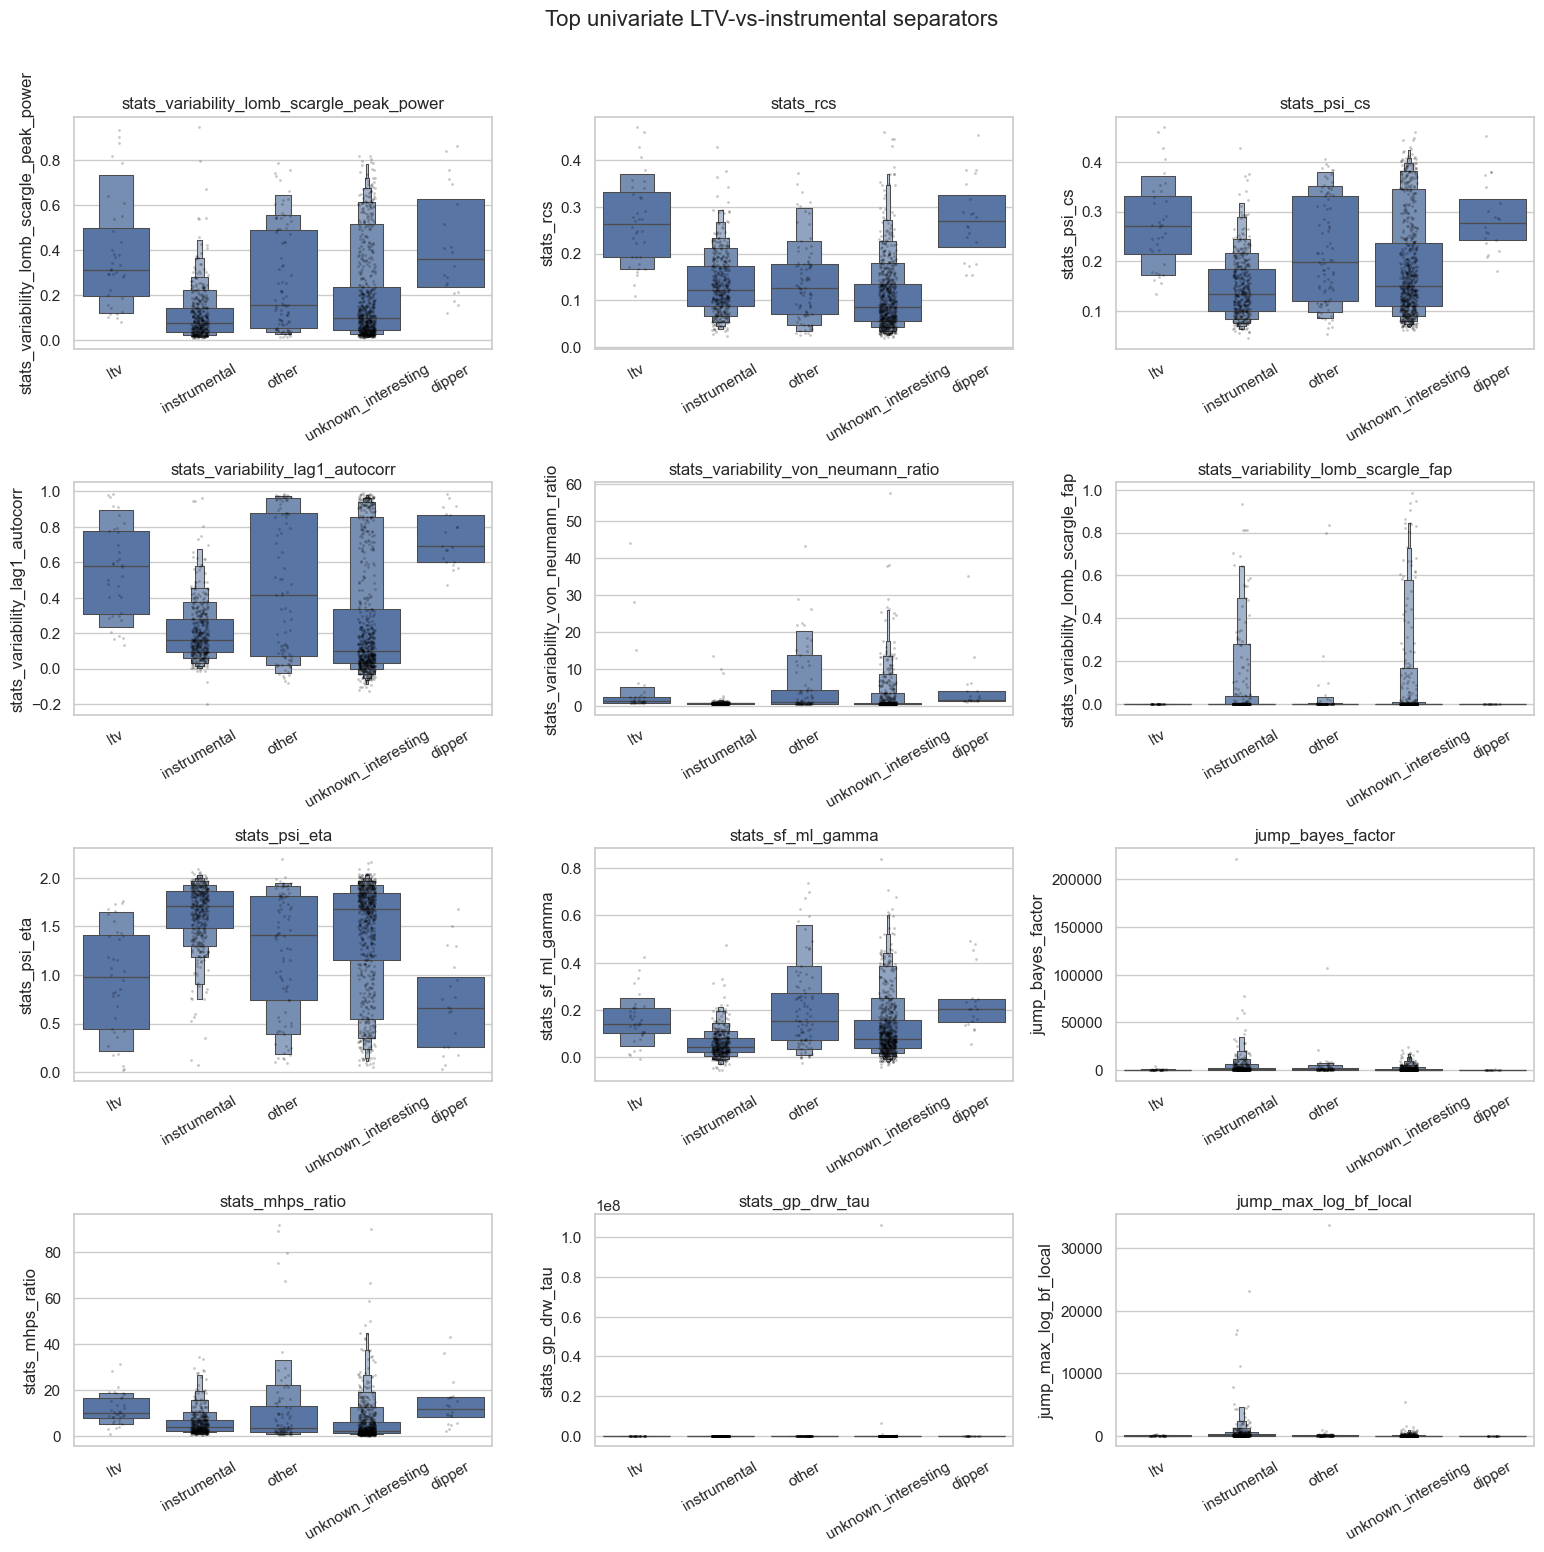

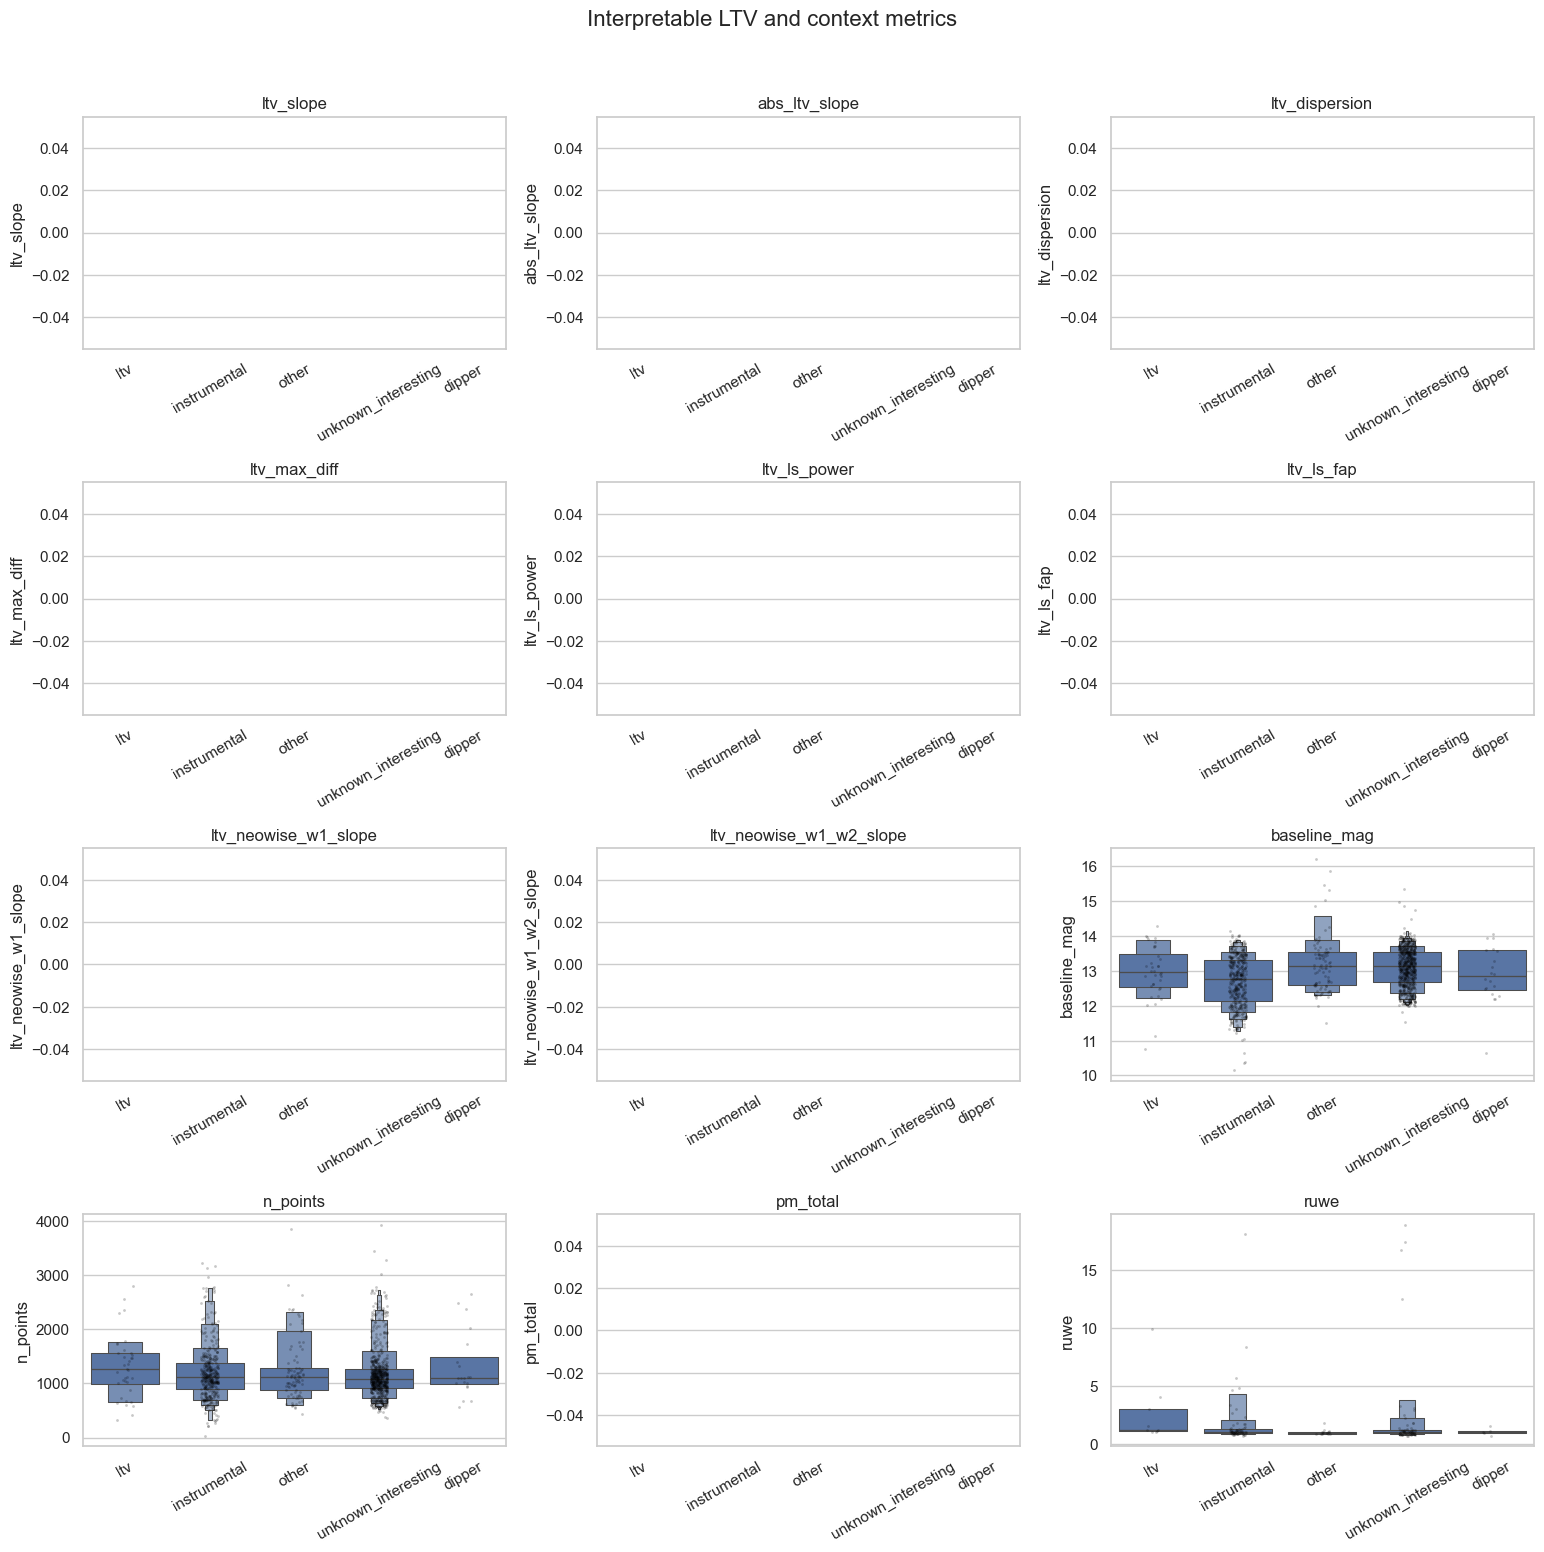

In [8]:
from malca.lightcurve_publication import (
    figsize_feature_grid,
)
def plot_feature_grid(features: list[str], data: pd.DataFrame, *, max_features: int = 12, title: str = "") -> None:
    features = [f for f in features if f in data.columns]
    features = features[:max_features]
    if not features:
        print("No features to plot.")
        return
    ncols = 3
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize_feature_grid(ncols, nrows), squeeze=False)
    plot_data = data.loc[data["event_class"].isin(CLASS_ORDER)].copy()
    plot_data["event_class"] = pd.Categorical(plot_data["event_class"], CLASS_ORDER, ordered=True)
    for ax, feature in zip(axes.ravel(), features):
        sns.boxenplot(data=plot_data, x="event_class", y=feature, order=CLASS_ORDER, ax=ax, showfliers=False)
        sns.stripplot(data=plot_data, x="event_class", y=feature, order=CLASS_ORDER, ax=ax, color="black", alpha=0.22, size=2)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
        ax.set_title(feature)
    for ax in axes.ravel()[len(features):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=16)
    fig.tight_layout()
    plt.show()

top_univariate_features = test_results.head(12)["feature"].tolist()
plot_feature_grid(top_univariate_features, analysis, title="Top univariate LTV-vs-instrumental separators")

handpicked_for_plot = [
    "ltv_slope", "abs_ltv_slope", "ltv_dispersion", "ltv_max_diff", "ltv_ls_power", "ltv_ls_fap",
    "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "baseline_mag", "n_points", "pm_total", "ruwe",
]
plot_feature_grid(handpicked_for_plot, analysis, title="Interpretable LTV and context metrics")


## Categorical And Flag Features

This section looks at low-cardinality flags and catalog matches. For binary flags it also computes Fisher's exact p-value for `ltv` vs `instrumental`; for general categories it reports Cramer's V.


In [9]:
def cramers_v(table: pd.DataFrame) -> float:
    table = table.loc[table.sum(axis=1) > 0, table.sum(axis=0) > 0]
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return float(np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1)))

categorical_rows = []
for col in low_card_cols:
    subset = binary_ltv_inst[["event_class", col]].dropna().copy()
    if subset.empty or subset[col].nunique(dropna=True) < 2:
        continue
    table = pd.crosstab(subset["event_class"], subset[col])
    fisher_p = np.nan
    if table.shape == (2, 2):
        try:
            fisher_p = stats.fisher_exact(table.to_numpy())[1]
        except Exception:
            fisher_p = np.nan
    categorical_rows.append({
        "feature": col,
        "n": int(table.to_numpy().sum()),
        "n_values": int(table.shape[1]),
        "cramers_v": cramers_v(table),
        "fisher_p_if_binary": fisher_p,
        "values": ", ".join(map(str, table.columns[:8])),
    })

cat_results = pd.DataFrame(categorical_rows)
if not cat_results.empty:
    cat_results["fisher_q_if_binary"] = bh_fdr(cat_results["fisher_p_if_binary"])
    cat_results = cat_results.sort_values(["fisher_q_if_binary", "cramers_v"], ascending=[True, False], na_position="last")
    display(cat_results.head(40))
else:
    print("No categorical features passed the screening criteria.")

IMPORTANT_CATS = [
    "ltv_passed_filters", "ltv_dust_candidate", "ltv_dust_excess", "ltv_vsx_match", "ltv_milliquas_match",
    "ltv_gaia_alert_match", "catalog_match", "catalog_source", "asassn_var_type", "gaia_var_class",
    "simbad_otype", "ztf_var_type", "microlens_match", "periodic_flag", "high_pm_flag",
]
IMPORTANT_CATS = [c for c in IMPORTANT_CATS if c in analysis.columns]

for col in IMPORTANT_CATS:
    display(Markdown(f"### {col}"))
    display(pd.crosstab(analysis["event_class"], analysis[col], margins=True, dropna=False))
    display(pd.crosstab(analysis["event_class"], analysis[col], normalize="index", dropna=False).round(3))


,feature,n,n_values,cramers_v,fisher_p_if_binary,values,fisher_q_if_binary
10,alerce_lc_class,454,2,0.160099,0.079295,", YSO",0.158590
12,baseline_source,454,2,0.053280,0.244773,"gp_sho, gp_sho,median_fallback",0.244773
4,jump_best_morph,454,4,0.263625,NaN,"fred, noise, none, paczynski",NaN
3,dip_best_morph,454,4,0.213171,NaN,"gaussian, noise, none, skew_gaussian",NaN
9,gaia_var_class,454,4,0.178266,NaN,", DSCT|GDOR|SXPHE, RS, YSO",NaN
6,sfr_name,454,4,0.161788,NaN,", Lupus (pos only), Orion Nebula Cluster, Scor...",NaN
8,asassn_var_type,454,3,0.113241,NaN,", ROT:, VAR",NaN
5,population,454,3,0.079282,NaN,"thick_disk_candidate, thin_disk_candidate, unk...",NaN
0,catalog_source,454,3,0.068352,NaN,", asassn_var, vsx",NaN
1,period_sources,454,3,0.068352,NaN,", asassn_var, vsx",NaN


### ltv_passed_filters

ltv_passed_filters,NaN,All
event_class,,
brightening_event,41,41
dipper,20,20
flare,3,3
instrumental,418,418
ltv,36,36
microlensing,34,34
mixed_dip_and_burst,2,2
other,89,89
periodic,5,5


ltv_passed_filters,NaN
event_class,
brightening_event,1.0
dipper,1.0
flare,1.0
instrumental,1.0
ltv,1.0
microlensing,1.0
mixed_dip_and_burst,1.0
other,1.0
periodic,1.0


### ltv_dust_candidate

...

periodic_flag,0,All
event_class,,
brightening_event,41,41
dipper,20,20
flare,3,3
instrumental,418,418
ltv,36,36
microlensing,34,34
mixed_dip_and_burst,2,2
other,89,89
periodic,5,5


periodic_flag,0
event_class,
brightening_event,1.0
dipper,1.0
flare,1.0
instrumental,1.0
ltv,1.0
microlensing,1.0
mixed_dip_and_burst,1.0
other,1.0
periodic,1.0


### high_pm_flag

high_pm_flag,NaN,All
event_class,,
brightening_event,41,41
dipper,20,20
flare,3,3
instrumental,418,418
ltv,36,36
microlensing,34,34
mixed_dip_and_burst,2,2
other,89,89
periodic,5,5


high_pm_flag,NaN
event_class,
brightening_event,1.0
dipper,1.0
flare,1.0
instrumental,1.0
ltv,1.0
microlensing,1.0
mixed_dip_and_burst,1.0
other,1.0
periodic,1.0


## Simple Predictive Check: Can A Baseline Model Separate LTV From Instrumental?

This is not intended as a production classifier. It is a sanity check: if cross-validated metrics are weak, there may not be an obvious statistical separator in the current feature set; if they are strong, inspect the coefficients and plots for candidate rules.


Rows: 454; positives/LTV: 36; negatives/instrumental: 418
Model numeric features: 191
Model categorical features: 13


,mean,std
roc_auc,0.793285,0.038163
average_precision,0.434664,0.140316
balanced_accuracy,0.730099,0.056707
f1,0.453922,0.083903


ROC AUC: 0.791
Average precision: 0.388
Balanced accuracy @ 0.5: 0.728
Confusion matrix @ 0.5 [rows=true, cols=pred]:


,pred_instrumental,pred_ltv
true_instrumental,388,30
true_ltv,17,19


              precision    recall  f1-score   support

instrumental       0.96      0.93      0.94       418
         ltv       0.39      0.53      0.45        36

    accuracy                           0.90       454
   macro avg       0.67      0.73      0.69       454
weighted avg       0.91      0.90      0.90       454



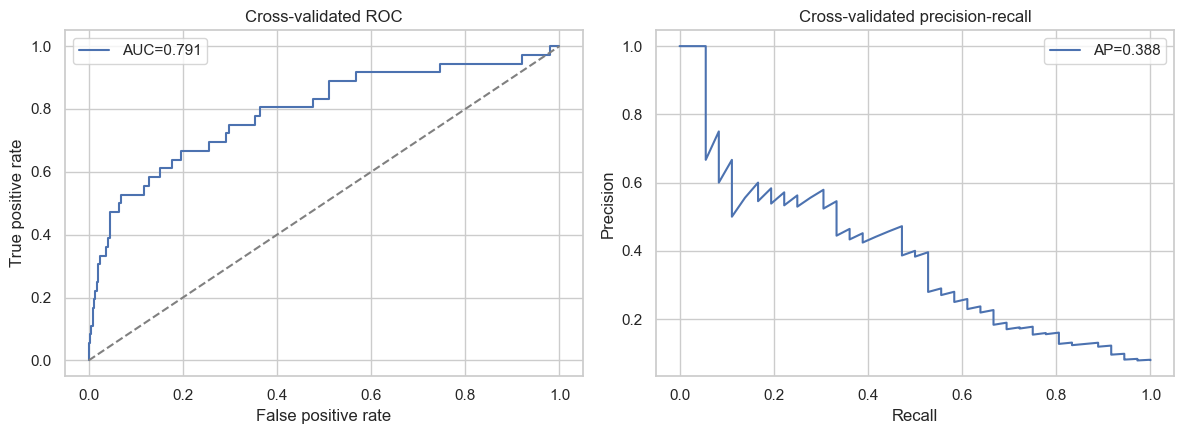

,candidate_id,asas_sn_id,event_class,interest_score,review_pass,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,baseline_mag,n_points,cv_ltv_probability
727,343598407644,343598407644,ltv,1,3,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,13.915033,1515.0,0.999999
664,257698611829,257698611829,ltv,2,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,14.005139,1777.0,0.999995
772,403727940257,403727940257,instrumental,2,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,13.394787,1271.0,0.999994
308,77309467421,77309467421,ltv,2,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,12.990007,315.0,0.999917
1216,481037066830,481037066830,instrumental,1,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,13.143000,1283.0,0.999771
923,60130665647,60130665647,ltv,2,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,13.430760,1122.0,0.999719
60,257698364407,257698364407,instrumental,4,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,12.773000,326.0,0.999437
894,575525835633,575525835633,instrumental,1,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,12.750770,1175.0,0.999379
499,601295818531,601295818531,ltv,1,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,12.504980,1485.0,0.999264
1113,300648281213,300648281213,ltv,3,2,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,13.151742,1246.0,0.999135


In [10]:
from malca.lightcurve_publication import (
    FIG_ROC_PR_TWO_COL,
)
model_data = binary_ltv_inst.copy()
y = model_data["event_class"].eq("ltv").astype(int)

# Use all sufficiently populated numeric features plus selected low-cardinality context flags.
model_numeric = []
for col in numeric_cols:
    if col in EXCLUDE_FEATURES:
        continue
    nonmissing_frac = model_data[col].notna().mean()
    if nonmissing_frac >= 0.40 and model_data[col].nunique(dropna=True) > 1:
        model_numeric.append(col)

model_categorical = []
for col in low_card_cols:
    if col in EXCLUDE_FEATURES:
        continue
    nonmissing_frac = model_data[col].notna().mean()
    if nonmissing_frac >= 0.40 and 1 < model_data[col].nunique(dropna=True) <= 12:
        model_categorical.append(col)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:  # older scikit-learn
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), model_numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", onehot)]), model_categorical),
    ],
    remainder="drop",
)

logit = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")),
])

print(f"Rows: {len(model_data):,}; positives/LTV: {int(y.sum()):,}; negatives/instrumental: {int((1-y).sum()):,}")
print(f"Model numeric features: {len(model_numeric)}")
print(f"Model categorical features: {len(model_categorical)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]
cv_scores = cross_validate(logit, model_data[model_numeric + model_categorical], y, cv=cv, scoring=scoring)
score_summary = pd.DataFrame({
    metric.replace("test_", ""): [cv_scores[metric].mean(), cv_scores[metric].std(ddof=1)]
    for metric in cv_scores
    if metric.startswith("test_")
}, index=["mean", "std"]).T

display(score_summary)

proba = cross_val_predict(logit, model_data[model_numeric + model_categorical], y, cv=cv, method="predict_proba")[:, 1]
pred = (proba >= 0.5).astype(int)
print("ROC AUC:", round(roc_auc_score(y, proba), 3))
print("Average precision:", round(average_precision_score(y, proba), 3))
print("Balanced accuracy @ 0.5:", round(balanced_accuracy_score(y, pred), 3))
print("Confusion matrix @ 0.5 [rows=true, cols=pred]:")
display(pd.DataFrame(confusion_matrix(y, pred), index=["true_instrumental", "true_ltv"], columns=["pred_instrumental", "pred_ltv"]))
print(classification_report(y, pred, target_names=["instrumental", "ltv"]))

fig, axes = plt.subplots(1, 2, figsize=FIG_ROC_PR_TWO_COL)
fpr, tpr, _ = roc_curve(y, proba)
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y, proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()
axes[0].set_title("Cross-validated ROC")

precision, recall, _ = precision_recall_curve(y, proba)
axes[1].plot(recall, precision, label=f"AP={average_precision_score(y, proba):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].set_title("Cross-validated precision-recall")
fig.tight_layout()
plt.show()

scored_binary = model_data[["candidate_id", "asas_sn_id", "event_class", "interest_score", "review_pass", "notes", "lc_path"] + [c for c in ["ltv_slope", "ltv_dispersion", "ltv_max_diff", "baseline_mag", "n_points"] if c in model_data.columns]].copy()
scored_binary["cv_ltv_probability"] = proba
display(scored_binary.sort_values("cv_ltv_probability", ascending=False).head(40))


## Model Coefficients

Positive coefficients push the baseline model toward `ltv`; negative coefficients push it toward `instrumental`. Correlated features can split or flip coefficients, so interpret these alongside the univariate plots.


,feature,coef_ltv_positive,abs_coef
43,num__dipper_n_valid_dips,1.239938,1.239938
154,num__stats_rcs,1.203329,1.203329
50,num__logg_gspphot,1.198065,1.198065
149,num__stats_skew,1.042367,1.042367
157,num__stats_harmonics_order,0.979082,0.979082
120,num__stats_variability_lag1_autocorr,0.953332,0.953332
52,num__distance_gspphot,-0.909706,0.909706
143,num__stats_max_slope,0.875774,0.875774
159,num__stats_harmonics_a0,0.812633,0.812633
176,num__stats_harmonics_phase_3,0.781806,0.781806


/var/folders/z5/95nmr_n10ls6x2913x09nzs80000gn/T/ipykernel_76907/1639982263.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, y="feature", x="coef_ltv_positive", ax=ax, palette="vlag")


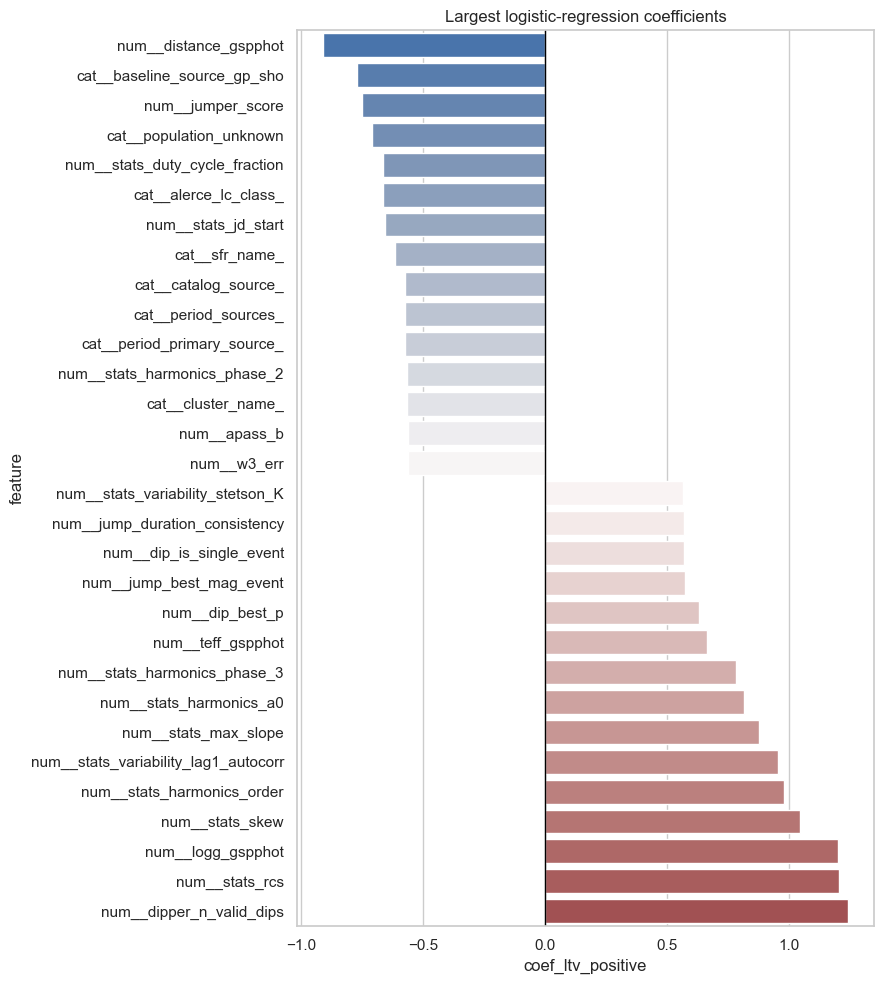

In [11]:
from malca.lightcurve_publication import (
    figsize_heatmap_two_col,
)
logit.fit(model_data[model_numeric + model_categorical], y)
try:
    feature_names = logit.named_steps["prep"].get_feature_names_out()
except Exception:
    feature_names = np.array(model_numeric + model_categorical, dtype=object)
coefs = logit.named_steps["clf"].coef_[0]
coef_table = pd.DataFrame({"feature": feature_names, "coef_ltv_positive": coefs})
coef_table["abs_coef"] = coef_table["coef_ltv_positive"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)
display(coef_table.head(50))

fig, ax = plt.subplots(figsize=figsize_heatmap_two_col(len(show_features)))
top_coef = coef_table.head(30).sort_values("coef_ltv_positive")
sns.barplot(data=top_coef, y="feature", x="coef_ltv_positive", ax=ax, palette="vlag")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest logistic-regression coefficients")
fig.tight_layout()
plt.show()


## Low-Dimensional View Of Reviewed Candidates

PCA is only a visual diagnostic, but it helps show whether labels occupy obviously different parts of numeric-feature space.


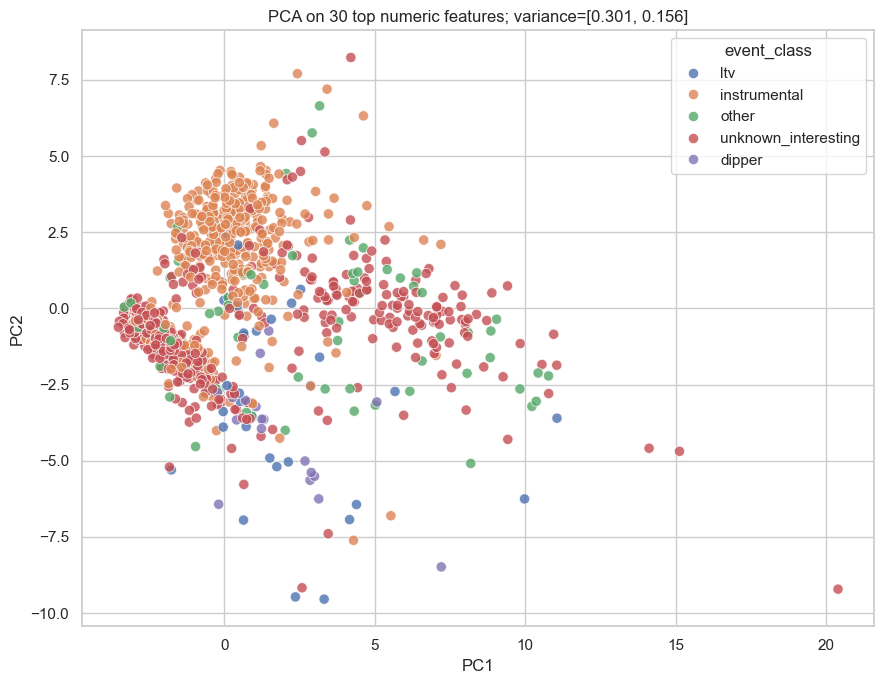

,candidate_id,event_class,PC1,PC2
440,481036586933,dipper,-0.637745,-2.784674
318,94489786439,dipper,-0.390433,-2.331736
844,515396131751,dipper,-0.234295,-2.748179
864,532576054353,dipper,-0.192359,-6.426385
666,25771086021,dipper,0.269609,-2.921202
21,146029419304,dipper,0.402322,-3.657349
903,592705518006,dipper,0.698631,-3.015850
206,549755992463,dipper,1.048860,-3.222677
360,240518636016,dipper,1.191122,-1.471552
794,446676921101,dipper,1.229293,-3.942090


In [12]:
from malca.lightcurve_publication import (
    FIG_TWO_COL_WIDTH,
)
pca_features = test_results.head(30)["feature"].tolist()
pca_features = [f for f in pca_features if f in analysis.columns]
if len(pca_features) < 3:
    pca_features = INTERPRETABLE_FEATURES[:20]

pca_data = analysis.loc[analysis["event_class"].isin(CLASS_ORDER), ["candidate_id", "event_class"] + pca_features].copy()
X = pca_data[pca_features].apply(pd.to_numeric, errors="coerce")
X = SimpleImputer(strategy="median").fit_transform(X)
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
pca_plot = pca_data[["candidate_id", "event_class"]].copy()
pca_plot["PC1"] = coords[:, 0]
pca_plot["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(FIG_TWO_COL_WIDTH, 5.0))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="event_class", hue_order=CLASS_ORDER, alpha=0.8, s=55, ax=ax)
ax.set_title(f"PCA on {len(pca_features)} top numeric features; variance={pca.explained_variance_ratio_.round(3).tolist()}")
fig.tight_layout()
plt.show()

display(pca_plot.sort_values(["event_class", "PC1"]).head(30))


## Explore `other`, `unknown_interesting`, And `dipper`

These groups are too small or heterogeneous for strong inference, so this section focuses on candidate lists and nearest-neighbor context in the feature space used above.


In [13]:
NON_PRIMARY_LABELS = ["other", "unknown_interesting", "dipper"]
for label in NON_PRIMARY_LABELS:
    display(Markdown(f"### {label}"))
    display(candidate_table(label, max_rows=120))

# Compare each non-primary class against LTV and instrumental medians for the interpretable metrics.
profile_features = [c for c in INTERPRETABLE_FEATURES if analysis[c].notna().sum() >= 10]
profile = (
    analysis.loc[analysis["event_class"].isin(CLASS_ORDER)]
    .groupby("event_class")[profile_features]
    .median(numeric_only=True)
    .T
)
display(profile)

# Nearest neighbors for rare labels relative to reviewed LTV/instrumental candidates.
neighbor_features = pca_features[:20]
neighbor_base = analysis.loc[analysis["event_class"].isin(["ltv", "instrumental", "other", "unknown_interesting", "dipper"]), ["candidate_id", "event_class"] + neighbor_features].copy()
Xn = neighbor_base[neighbor_features].apply(pd.to_numeric, errors="coerce")
Xn = SimpleImputer(strategy="median").fit_transform(Xn)
Xn = StandardScaler().fit_transform(Xn)
neighbor_rows = []
for idx, row in neighbor_base.iterrows():
    if row["event_class"] not in NON_PRIMARY_LABELS:
        continue
    local_index = neighbor_base.index.get_loc(idx)
    d = np.sqrt(((Xn - Xn[local_index]) ** 2).sum(axis=1))
    order = np.argsort(d)
    for rank, j in enumerate(order[1:8], start=1):
        neighbor_rows.append({
            "candidate_id": row["candidate_id"],
            "event_class": row["event_class"],
            "neighbor_rank": rank,
            "neighbor_candidate_id": neighbor_base.iloc[j]["candidate_id"],
            "neighbor_event_class": neighbor_base.iloc[j]["event_class"],
            "distance": d[j],
        })
neighbors = pd.DataFrame(neighbor_rows)
display(neighbors)


### other

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
290,652835815168,652835815168,other,reviewed,4,2,2026-03-20 21:09:36.701018+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.968122,1204.0,3.0,None,NaN,NaN,0.000000,22.778900,0,,,,,,None
419,386547289419,386547289419,other,reviewed,4,3,2026-03-20 20:48:12.024244+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.371770,1201.0,6.0,None,1.018635,NaN,19.867276,0.000000,0,,ROT:,YSO,SB*,,None
456,515396207917,515396207917,other,reviewed,4,2,2026-03-20 20:18:11.810720+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,11.994506,1499.0,4.0,None,1.204014,NaN,0.000000,20.035418,0,,,,RR*,,None
437,472446626839,472446626839,other,reviewed,4,2,2026-03-20 19:51:10.047589+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.237051,1008.0,4.0,None,0.834857,NaN,12.493998,0.000000,0,,,,EB*,,None
907,584115779011,584115779011,other,reviewed,4,2,2026-03-20 06:39:57.740125+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.485041,2093.0,6.0,None,NaN,NaN,18.042140,0.000000,0,,,,EB*,,None
526,652835797559,652835797559,other,reviewed,4,2,2026-03-20 06:38:22.372817+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.273613,1138.0,3.0,None,0.985791,NaN,18.205948,0.000000,0,,,,,,None
535,68720667043,68720667043,other,reviewed,4,2,2026-03-20 05:46:32.353666+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.294000,669.0,2.0,None,0.821292,NaN,19.556165,0.000000,0,,,,EB*,,None
93,343598268424,343598268424,other,reviewed,4,2,2026-03-20 05:26:29.430884+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.989107,2350.0,6.0,None,NaN,NaN,20.705012,-0.441348,0,,YSO,,,,None
1081,240519014553,240519014553,other,reviewed,4,2,2026-03-20 05:26:12.668185+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.492181,926.0,6.0,None,NaN,NaN,20.723628,-0.218134,0,,YSO,,LP*,,None
676,274878275229,274878275229,other,reviewed,4,2,2026-03-20 02:20:27.828023+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.679791,991.0,4.0,None,NaN,NaN,20.105618,0.000000,0,,,,EB*,,None


### unknown_interesting

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
229,584115757436,584115757436,unknown_interesting,needs_followup,4,1,2026-03-22 17:14:31.648862+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.669065,1108.0,3.0,None,NaN,NaN,0.000000,16.382227,0,,,DSCT|GDOR|SXPHE,Pu*,,None
244,601295591834,601295591834,unknown_interesting,needs_followup,4,1,2026-03-22 17:14:13.951231+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.747103,1251.0,4.0,None,NaN,3.0,0.000000,-0.467168,1,asassn_var,ROT:,,*,,None
724,343597961057,343597961057,unknown_interesting,reviewed,4,1,2026-03-22 16:27:03.037328+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.571922,1015.0,5.0,None,NaN,3.0,22.950320,0.000000,1,ztf_periodic,,,EB*,EA,None
1368,94490667944,94490667944,unknown_interesting,reviewed,4,3,2026-03-20 21:25:39.987860+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.190754,663.0,4.0,None,NaN,NaN,0.000000,21.368117,0,,,,,,None
320,94490663224,94490663224,unknown_interesting,reviewed,4,2,2026-03-20 21:25:14.987547+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.614831,696.0,4.0,None,NaN,NaN,0.000000,-1.801169,0,,,,Em*,,None
1366,94490543907,94490543907,unknown_interesting,reviewed,4,2,2026-03-20 21:24:59.908670+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.403983,824.0,2.0,None,NaN,NaN,0.000000,-0.766676,0,,,,,,None
1350,85899736527,85899736527,unknown_interesting,reviewed,4,2,2026-03-20 21:22:04.737861+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.144975,572.0,3.0,None,NaN,NaN,0.000000,21.682697,0,,,,,,None
310,77310113008,77310113008,unknown_interesting,reviewed,4,2,2026-03-20 21:21:35.172636+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.708599,364.0,2.0,None,NaN,NaN,0.000000,15.677000,0,,,,Em*,,None
1344,68720339248,68720339248,unknown_interesting,reviewed,4,2,2026-03-20 21:13:18.921978+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.505707,1104.0,3.0,None,NaN,NaN,0.000000,0.578188,0,,,,,,None
979,661425400860,661425400860,unknown_interesting,reviewed,4,2,2026-03-20 21:11:19.165443+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.665000,1129.0,3.0,None,NaN,NaN,0.000000,-1.763190,0,,,,,,None


### dipper

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
657,249109084130,249109084130,dipper,reviewed,4,2,2026-03-19 05:19:56.656011+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.954414,2644.0,9.0,None,NaN,NaN,0.000000,-0.404836,0,,,,Y*O,,None
33,180388903123,180388903123,dipper,reviewed,4,2,2026-03-19 04:41:57.365051+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.572548,1104.0,5.0,None,NaN,NaN,-1.040463,0.000000,0,,,,*,,None
1224,498216222923,498216222923,dipper,reviewed,3,3,2026-03-20 20:06:46.892226+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.097669,1115.0,3.0,None,NaN,NaN,0.332474,0.000000,0,,,,,,None
360,240518636016,240518636016,dipper,reviewed,2,2,2026-06-10 18:48:29.416974+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.345930,1007.0,5.0,None,1.566879,NaN,19.800610,18.639169,0,,,,*,,None
794,446676921101,446676921101,dipper,reviewed,2,3,2026-06-01 18:10:39.761894+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.949305,1729.0,5.0,None,NaN,NaN,-0.560155,0.000000,0,,,,,,None
206,549755992463,549755992463,dipper,reviewed,2,5,2026-06-01 18:05:18.438723+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.928863,1109.0,3.0,None,NaN,NaN,-1.425498,0.000000,0,,,,,,None
864,532576054353,532576054353,dipper,reviewed,2,2,2026-03-20 06:43:15.433996+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.630545,2380.0,6.0,None,NaN,NaN,17.788846,0.000000,0,,,,,,None
636,223338997633,223338997633,dipper,reviewed,1,2,2026-03-20 20:49:57.550421+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.594424,1097.0,6.0,None,NaN,NaN,19.852360,0.000000,0,,,,,,None
545,8591303502,8591303502,dipper,reviewed,1,2,2026-03-20 20:07:24.393034+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,12.191586,1329.0,5.0,None,0.891140,NaN,0.102236,0.000000,0,,,,Em*,,None
194,523986354332,523986354332,dipper,reviewed,1,2,2026-03-20 19:59:19.205763+00:00,,/home/calder/code/malca/output/runs/runs_march...,None,None,None,None,None,None,None,None,None,None,None,None,None,13.289000,1031.0,4.0,None,NaN,NaN,1.291065,0.000000,0,,,,*,,None


event_class,dipper,instrumental,ltv,other,unknown_interesting
baseline_mag,12.840628,12.778109,12.962689,13.138825,13.148639
n_points,1101.500000,1114.000000,1256.500000,1115.000000,1088.500000
n_cameras,5.000000,4.000000,5.000000,4.000000,4.000000
ruwe,1.017348,1.028652,1.176501,0.918093,1.026257
A_v_3d,0.087820,0.092002,0.112000,0.128568,0.000000
ebv_3d,0.175835,0.075695,0.056742,0.170361,0.146041
lsp_period,281.244995,3.447600,392.896004,37.718999,2.186000
stats_photometry_std_mag,0.048811,0.057095,0.053424,0.048420,0.026366
stats_photometry_robust_sigma_mag,0.036425,0.045961,0.043605,0.033878,0.020756
stats_amplitude,0.098265,0.118184,0.107981,0.098695,0.056442


,candidate_id,event_class,neighbor_rank,neighbor_candidate_id,neighbor_event_class,distance
0,103079849011,unknown_interesting,1,240518636016,dipper,2.600052
1,103079849011,unknown_interesting,2,25770889321,ltv,3.012350
2,103079849011,unknown_interesting,3,8590244035,unknown_interesting,3.017552
3,103079849011,unknown_interesting,4,644245811932,other,3.441996
4,103079849011,unknown_interesting,5,51540459002,other,3.476046
...,...,...,...,...,...,...
5714,85899911046,unknown_interesting,3,455266674007,unknown_interesting,0.412257
5715,85899911046,unknown_interesting,4,575526022021,other,0.424229
5716,85899911046,unknown_interesting,5,352188436417,unknown_interesting,0.431633
5717,85899911046,unknown_interesting,6,489627381354,unknown_interesting,0.434622


## Light-Curve Inspection Helpers

Use `plot_candidate_lightcurve("ltv_...")` or `plot_class_examples("ltv", n=4)` to inspect the source `.dat2` files. The y-axis is inverted because these are magnitudes.


In [14]:
from malca.review.paper_candidates import (
    assign_review_bucket,
    resolve_bucket_label,
    plot_candidate_lightcurve as _plot_candidate_lightcurve,
    plot_class_examples as _plot_class_examples,
)

if "review_bucket" not in analysis.columns:
    analysis = analysis.copy()
    analysis["review_bucket"] = analysis.apply(assign_review_bucket, axis=1)

from malca.lightcurve_publication import plot_lightcurve_panel


def resolve_lc_path(value: object) -> Path | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    raw = str(value)
    if not raw:
        return None
    path = Path(raw).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([
            REPO_ROOT / path,
            RUN_DIR / path,
            RUN_DIR / "bundle_assets" / "lightcurves" / path.name,
            LIGHTCURVE_DIRS[0] / path.name,
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path


def read_dat2(path: Path) -> pd.DataFrame:
    cols = ["time", "mag", "mag_err", "quality_flag", "camera", "field_flag", "unknown_flag", "image"]
    df = pd.read_csv(path, sep=r"\s+", header=None, names=cols, comment="#", engine="python")
    for col in ["time", "mag", "mag_err", "quality_flag", "camera", "field_flag", "unknown_flag"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=["time", "mag"])


def plot_candidate_lightcurve_legacy(candidate_id: str, *, color_by_camera: bool = True, max_legend: int = 12) -> pd.DataFrame:
    rows = analysis.loc[analysis["candidate_id"].eq(candidate_id)]
    if rows.empty:
        raise KeyError(f"candidate_id not found: {candidate_id}")
    row = rows.iloc[0]
    path = resolve_lc_path(row.get("lc_path"))
    if path is None or not path.exists():
        raise FileNotFoundError(f"No light curve file found for {candidate_id}: {row.get('lc_path')}")
    lc = read_dat2(path)
    fig, ax = plt.subplots(figsize=FIG_LC_SINGLE_COL)
    camera_count = lc["camera"].nunique(dropna=True) if "camera" in lc.columns else 0
    plot_lightcurve_panel(
        ax,
        lc,
        time_col="time",
        value_col="mag",
        error_col="mag_err",
        camera_col="camera" if color_by_camera and "camera" in lc.columns else None,
        group_by="camera" if color_by_camera and "camera" in lc.columns else "none",
        legend="auto" if color_by_camera and camera_count <= max_legend else "none",
        marker_size=3.0,
        time_offset="none",
        xlabel="time",
        ylabel="mag",
        title=(
            f"{candidate_id} | class={row.get('event_class')} | score={row.get('interest_score')} | "
            f"ltv_slope={row.get('ltv_slope')} | dispersion={row.get('ltv_dispersion')}"
        ),
    )
    fig.tight_layout()
    plt.show()
    display(row[KEY_DISPLAY_COLS].to_frame().T)
    return lc


def plot_candidate_lightcurve(candidate_id: str, *, color_by_camera: bool = True, max_legend: int = 12) -> pd.DataFrame:
    try:
        return _plot_candidate_lightcurve(analysis, str(candidate_id), run_dir=RUN_DIR, color_by_camera=color_by_camera, max_legend=max_legend)
    except Exception:
        return plot_candidate_lightcurve_legacy(candidate_id, color_by_camera=color_by_camera, max_legend=max_legend)


def plot_class_examples(label: str, n: int = 4, *, sort_by: str = "interest_score") -> list[pd.DataFrame]:
    bucket = resolve_bucket_label(analysis, label)
    try:
        return _plot_class_examples(analysis, bucket, n=n, sort_by=sort_by, run_dir=RUN_DIR)
    except Exception:
        data = analysis.loc[analysis["event_class"].eq(label)].copy()
        if data.empty:
            print(f"No rows for {label}")
            return []
        ascending = sort_by not in {"interest_score", "updated_at", "ltv_dispersion", "ltv_max_diff"}
        data = data.sort_values([sort_by, "candidate_id"], ascending=[not ascending, True]).head(n)
        out = []
        for cid in data["candidate_id"]:
            try:
                out.append(plot_candidate_lightcurve_legacy(cid))
            except Exception as exc:
                print(f"{cid}: {exc}")
        return out


## Example Light Curves

These examples are chosen from each reviewed class. Change the `n` values or call `plot_candidate_lightcurve()` with any candidate ID from the tables above.


### ltv examples

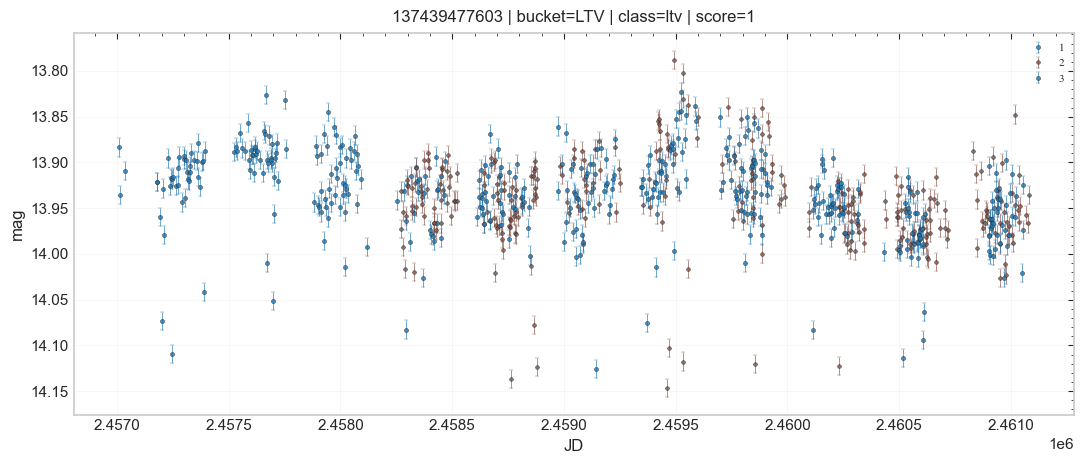

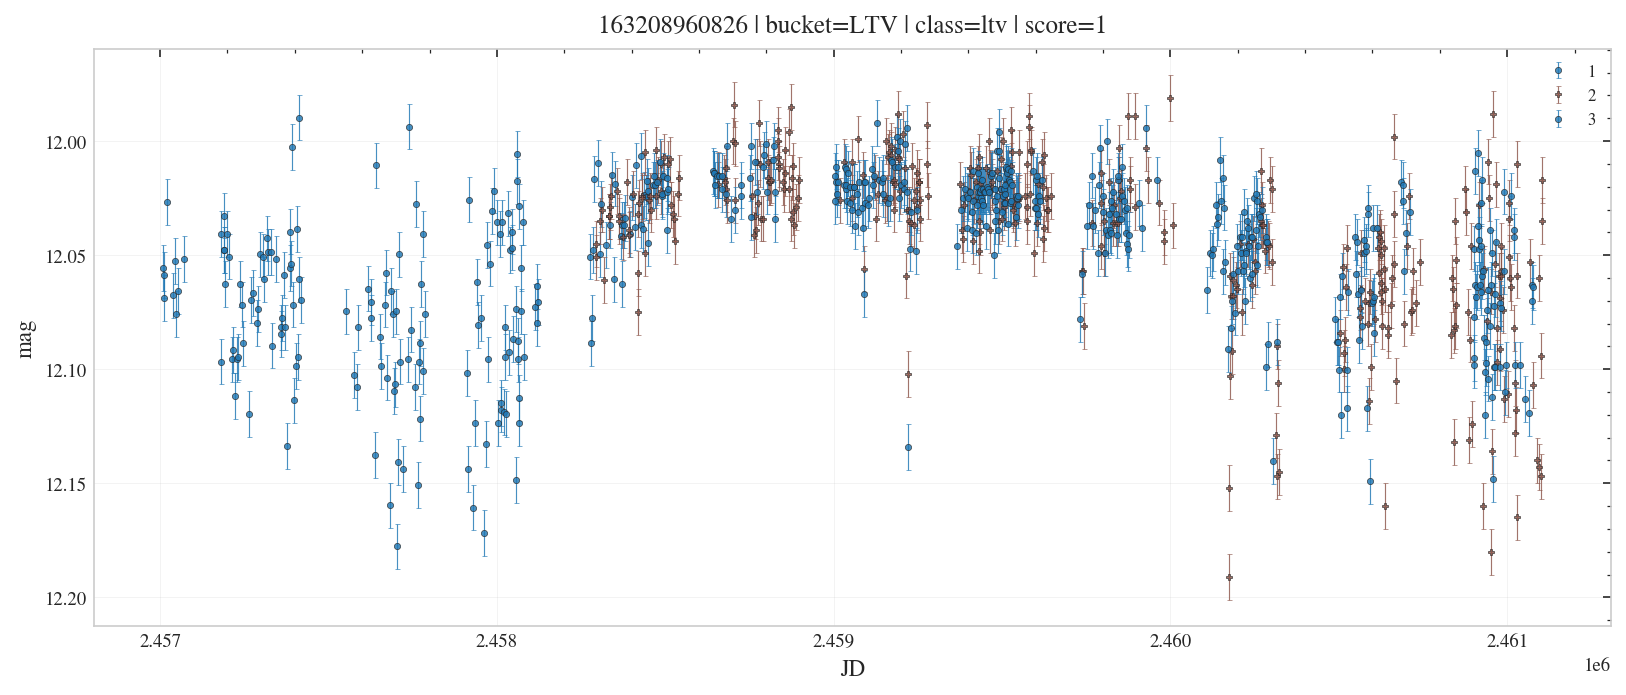

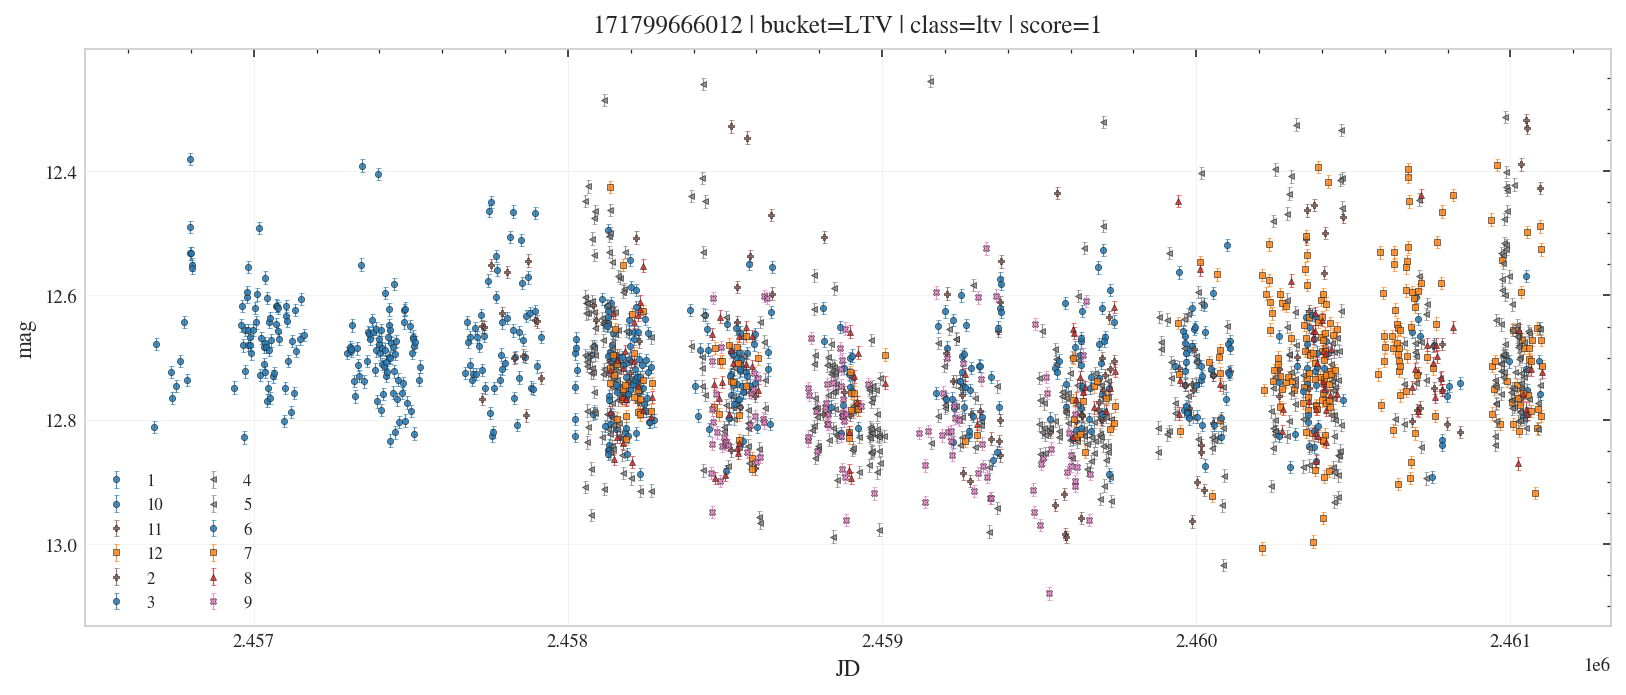

### instrumental examples

No rows for bucket=instrumental


### other examples

No rows for bucket=other


### unknown_interesting examples

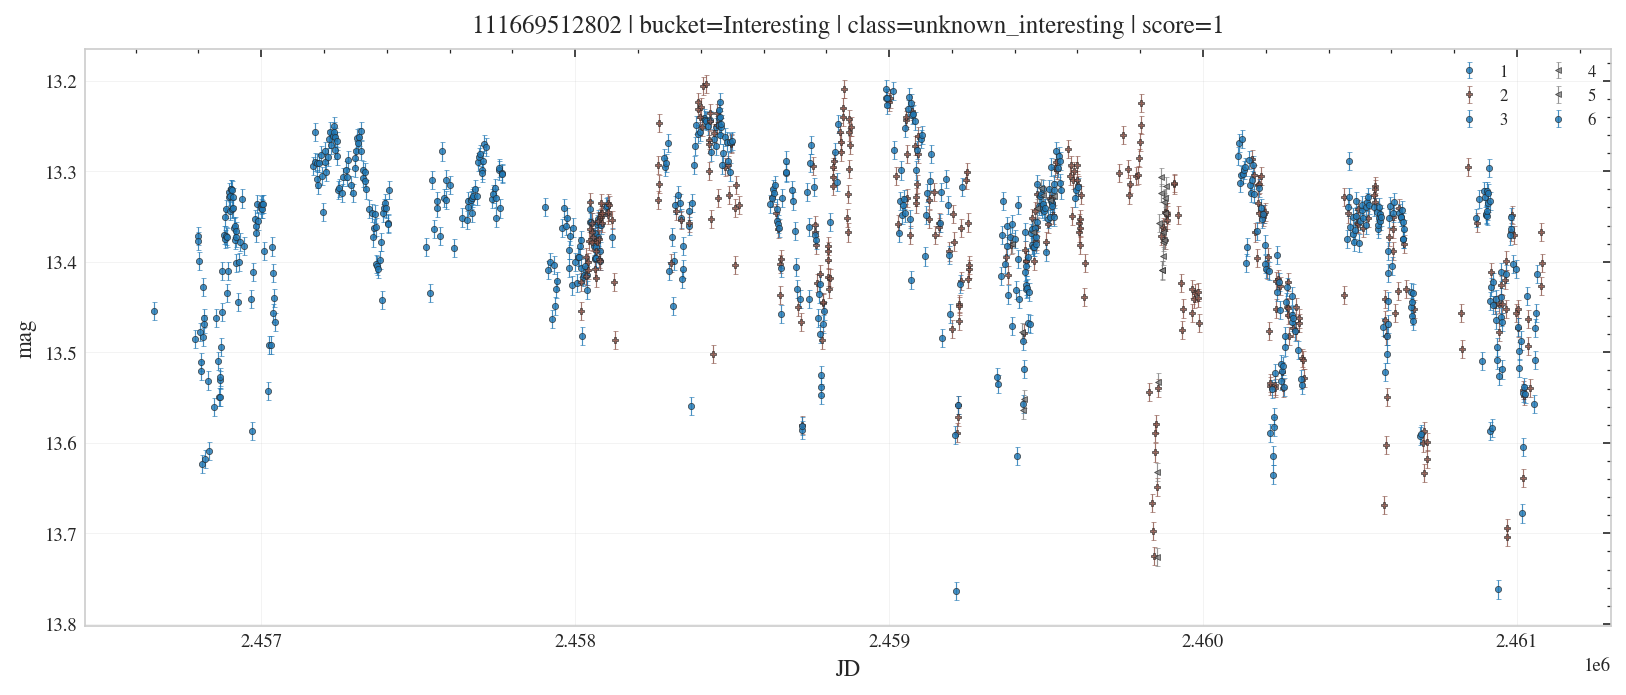

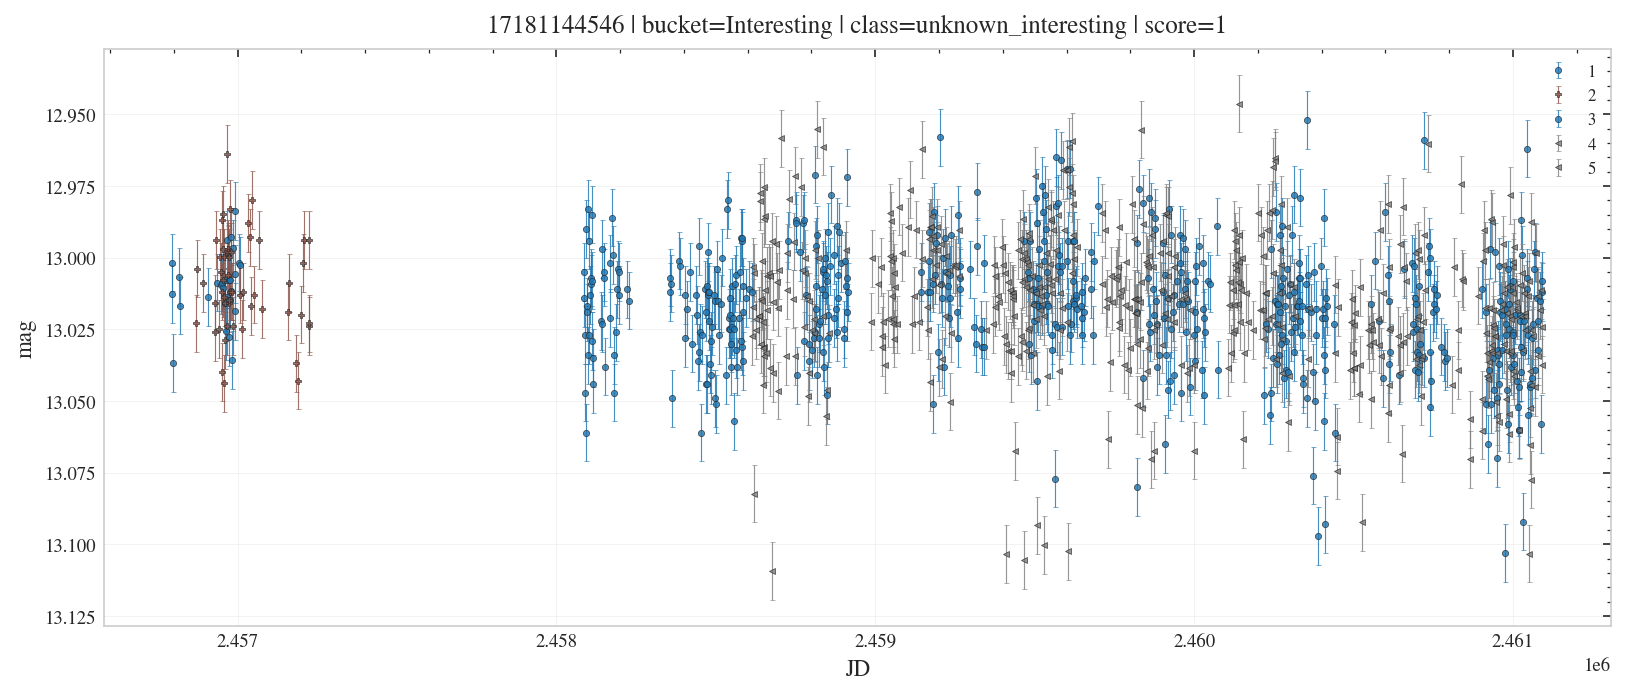

### dipper examples

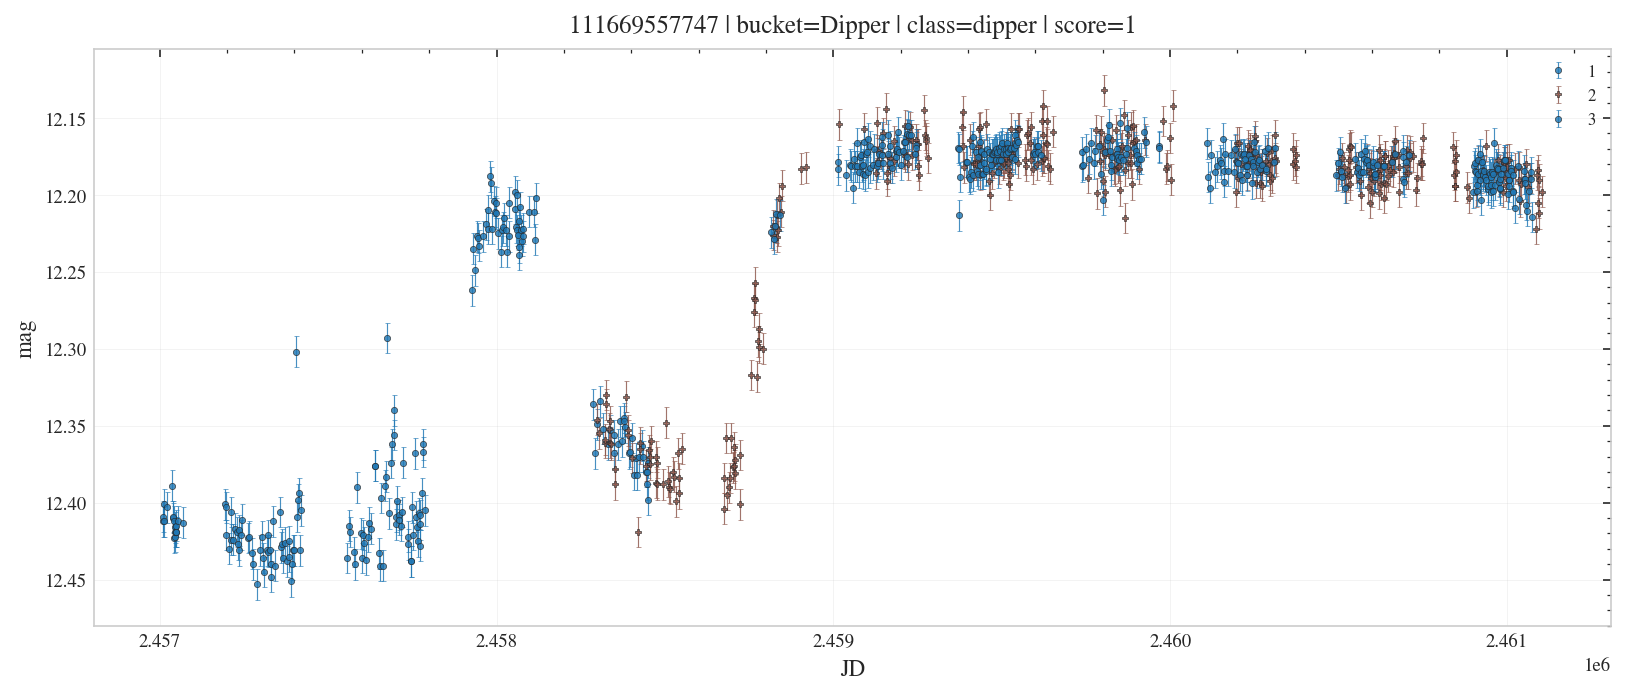

In [15]:
for label, n in [("ltv", 3), ("instrumental", 3), ("other", 3), ("unknown_interesting", 2), ("dipper", 1)]:
    display(Markdown(f"### {label} examples"))
    _ = plot_class_examples(label, n=n, sort_by="interest_score")


## Candidate Rule Sandbox

Use this cell to test candidate cuts suggested by the plots and statistics. The example is intentionally conservative and should be edited after inspecting the results above.


In [16]:
def evaluate_rule(mask: pd.Series, data: pd.DataFrame = binary_ltv_inst) -> pd.DataFrame:
    selected = data.loc[mask.reindex(data.index, fill_value=False)].copy()
    rows = []
    for label in ["ltv", "instrumental"]:
        label_total = int(data["event_class"].eq(label).sum())
        label_selected = int(selected["event_class"].eq(label).sum())
        rows.append({
            "event_class": label,
            "selected": label_selected,
            "total": label_total,
            "recall_within_class": label_selected / label_total if label_total else np.nan,
            "composition_of_selected": label_selected / len(selected) if len(selected) else np.nan,
        })
    return pd.DataFrame(rows)

# Edit this based on the features that look useful in test_results / plots.
rule = pd.Series(True, index=analysis.index)
for col, op, value in [
    ("ltv_passed_filters", "==", 1),
    # ("ltv_dispersion", ">", 2.0),
    # ("abs_ltv_slope", ">", 0.25),
]:
    if col not in analysis.columns:
        continue
    if op == "==":
        rule &= analysis[col].eq(value)
    elif op == ">":
        rule &= pd.to_numeric(analysis[col], errors="coerce").gt(value)
    elif op == "<":
        rule &= pd.to_numeric(analysis[col], errors="coerce").lt(value)

display(evaluate_rule(rule))
display(analysis.loc[rule & analysis["event_class"].isin(["ltv", "instrumental"]), KEY_DISPLAY_COLS].head(80))


,event_class,selected,total,recall_within_class,composition_of_selected
0,ltv,0,36,0.0,NaN
1,instrumental,0,418,0.0,NaN


,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match


## Export Optional Tables

Uncomment this cell if you want CSV snapshots of the most useful tables next to the notebook.


In [17]:
# out_dir = REPO_ROOT / "output" / "ltv" / "analysis_tables"
# out_dir.mkdir(parents=True, exist_ok=True)
# candidate_table(None, max_rows=len(reviewed)).to_csv(out_dir / "reviewed_ltv_candidate_table.csv", index=False)
# test_results.to_csv(out_dir / "ltv_vs_instrumental_numeric_tests.csv", index=False)
# coef_table.to_csv(out_dir / "ltv_vs_instrumental_logit_coefficients.csv", index=False)
# print(f"Wrote tables to {out_dir}")
